<a href="https://colab.research.google.com/github/MdRafiuzzamanSowrov/Basic_Keylogger/blob/main/GenEdgeGuard%20Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
import os
import pandas as pd
import glob

# Mount Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Path to your specific Colab folder
folder_path = '/content/drive/MyDrive/Colab'

# Find all CSV files inside this folder
dataset_paths = glob.glob(os.path.join(folder_path, "*.csv"))

print(f"Found {len(dataset_paths)} datasets:")
for path in dataset_paths:
    print(os.path.basename(path))

Found 8 datasets:
benign_train.csv
DNS_Spoofing.csv
Recon-PortScan.csv
Mirai-UDP-Plain.csv
DDos-SYN_Flood_Merge.csv
DDos-UDP_Flood-Merge.csv
DDos-TCP_Flood_Merge.csv
Mirai-greip_Flood_Merge.csv


In [ ]:
BASE = "/content/drive/MyDrive/Colab"
DATA_DIR = BASE
MODEL_DIR = BASE
SCRIPT_DIR = BASE

print("Files in folder:", os.listdir(BASE))

Files in folder: ['Untitled0.ipynb', 'benign_train.csv', 'DNS_Spoofing.csv', 'Recon-PortScan.csv', 'Mirai-UDP-Plain.csv', 'DDos-SYN_Flood_Merge.csv', 'DDos-UDP_Flood-Merge.csv', 'DDos-TCP_Flood_Merge.csv', 'Mirai-greip_Flood_Merge.csv', 'clip_high.npy', 'scaler_final.save', 'clip_low.npy', 'vae_best.pth']


In [ ]:
WORKDIR = "/content/run"
os.makedirs(WORKDIR, exist_ok=True)
os.makedirs(f"{WORKDIR}/results_correct", exist_ok=True)
os.makedirs(f"{WORKDIR}/figures", exist_ok=True)

for fname in os.listdir(BASE):
    src = os.path.join(BASE, fname)
    dst = os.path.join(WORKDIR, fname)
    if os.path.isfile(src) and not os.path.exists(dst):
        os.symlink(src, dst)
        if fname.endswith((".npy", ".save", ".pth")):
            dst2 = os.path.join(WORKDIR, "results_correct", fname)
            if not os.path.exists(dst2):
                os.symlink(src, dst2)

os.chdir(WORKDIR)
print("✓ Current directory:", os.getcwd())
print("✓ Files ready:", os.listdir(WORKDIR))
print("✓ results_correct/:", os.listdir(f"{WORKDIR}/results_correct"))

✓ Current directory: /content/run
✓ Files ready: ['figures', 'Recon-PortScan.csv', 'DDos-UDP_Flood-Merge.csv', 'DDos-SYN_Flood_Merge.csv', 'vae_best.pth', 'Mirai-UDP-Plain.csv', 'DNS_Spoofing.csv', 'Mirai-greip_Flood_Merge.csv', 'clip_low.npy', 'clip_high.npy', 'scaler_final.save', 'benign_train.csv', 'Untitled0.ipynb', 'DDos-TCP_Flood_Merge.csv', 'results_correct']
✓ results_correct/: ['vae_best.pth', 'clip_low.npy', 'clip_high.npy', 'scaler_final.save']


In [ ]:
from IPython.display import Image, display
import glob

_shown_figures = set()

def _auto_show_figures(*args, **kwargs):
    fig_dir = f"{WORKDIR}/figures"
    if not os.path.exists(fig_dir):
        return
    for f in sorted(glob.glob(f"{fig_dir}/*.png")):
        if f not in _shown_figures:
            display(Image(filename=f))
            _shown_figures.add(f)

get_ipython().events.register('post_run_cell', _auto_show_figures)
print("✓ Auto figure display enabled")

✓ Auto figure display enabled


In [ ]:
import numpy as np

tau_value = float(np.load("results_correct/tau_final.npy"))
np.save("results_correct/threshold.npy", tau_value)
print(f"✓ Created threshold.npy with tau = {tau_value:.4f}")

✓ Created threshold.npy with tau = 0.3972


In [ ]:
!pip install shap imbalanced-learn joblib -q

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import joblib
import json
import os

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

class VAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc_fc   = nn.Linear(7, 32)
        self.enc_mu   = nn.Linear(32, 8)
        self.enc_logv = nn.Linear(32, 8)
        self.dec_fc   = nn.Linear(8, 32)
        self.dec_out  = nn.Linear(32, 7)
    def encode(self, x):
        h = torch.relu(self.enc_fc(x))
        return self.enc_mu(h), self.enc_logv(h)
    def reparameterize(self, mu, lv):
        return mu + torch.exp(0.5 * lv) * torch.randn_like(lv)
    def decode(self, z):
        return self.dec_out(torch.relu(self.dec_fc(z)))
    def forward(self, x):
        mu, lv = self.encode(x)
        return self.decode(self.reparameterize(mu, lv)), mu, lv

# ── Load model ────────────────────────────────────────────────
model = VAE()
model.load_state_dict(torch.load("results_correct/vae_best.pth", map_location="cpu"))
model.eval()

scaler   = joblib.load("results_correct/scaler_final.save")
clip_lo  = np.load("results_correct/clip_low.npy")
clip_hi  = np.load("results_correct/clip_high.npy")

# ── FIX C1: Compute tau with fixed seed ───────────────────────
import pandas as pd
df_b = pd.read_csv("benign_train.csv")
FEATURE_COLS = ["pkt_len_mean","pkt_len_std","inter_arrival_mean","inter_arrival_std",
                "flow_duration","pkt_rate","payload_entropy"]

np.random.seed(SEED)
idx = np.random.permutation(len(df_b))
b_val_raw = df_b[FEATURE_COLS].values.astype(np.float64)[idx[70000:85000]]

def clean_norm(X):
    for c in range(X.shape[1]):
        m = ~np.isfinite(X[:, c])
        if m.any(): X[m, c] = np.nanmedian(X[~m, c])
    return scaler.transform(np.clip(X, clip_lo, clip_hi))

b_val_n = clean_norm(b_val_raw)

# CRITICAL: fix seed before inference (reparameterize uses randn)
torch.manual_seed(SEED)
with torch.no_grad():
    X_val_t = torch.tensor(b_val_n, dtype=torch.float32)
    mu, lv  = model.encode(X_val_t)
    # Use MEAN only (deterministic) for threshold — eliminates stochasticity
    xr_det  = model.decode(mu)  # no reparameterization = deterministic
    val_errs_det = ((X_val_t - xr_det) ** 2).mean(dim=1).numpy()

tau_det = float(np.percentile(val_errs_det, 99))
print(f"Deterministic tau (using mu, no reparam): {tau_det:.4f}")
print(f"Val error mean: {val_errs_det.mean():.4f}, std: {val_errs_det.std():.4f}")
print(f"Val FPR at tau: {(val_errs_det > tau_det).mean()*100:.2f}%")

# Also stochastic with fixed seed
torch.manual_seed(SEED)
with torch.no_grad():
    X_val_t2 = torch.tensor(b_val_n, dtype=torch.float32)
    xr2, mu2, lv2 = model(X_val_t2)
    val_errs_stoch = ((X_val_t2 - xr2) ** 2).mean(dim=1).numpy()
tau_stoch = float(np.percentile(val_errs_stoch, 99))
print(f"\nStochastic tau (seed={SEED}, with reparam): {tau_stoch:.4f}")

# Save deterministic tau as THE canonical tau
np.save("results_correct/tau_final.npy", tau_det)
print(f"\n✓ Saved canonical tau = {tau_det:.4f} to results_correct/tau_final.npy")
print("  Use deterministic inference (decode(mu) not decode(reparameterize(mu,lv)))")
print("  for ALL threshold computation and evaluation — eliminates randomness entirely")

# ── FIX C2: Compute actual Lipschitz constant ─────────────────
print("\n" + "="*60)
print("FIX C2: LIPSCHITZ CONSTANT COMPUTATION")
print("="*60)
print("L(E) <= product of spectral norms of all weight matrices")
print("Encoder path: enc_fc -> relu -> enc_mu -> reparameterize -> dec_fc -> relu -> dec_out")
print("(using deterministic path: enc_fc -> relu -> enc_mu -> dec_fc -> relu -> dec_out)\n")

layers_info = []
total_L = 1.0

# All weight matrices in the forward path
weight_matrices = [
    ("W_enc_fc  (7→32)",  model.enc_fc.weight.data.numpy()),
    ("W_enc_mu  (32→8)",  model.enc_mu.weight.data.numpy()),
    ("W_dec_fc  (8→32)",  model.dec_fc.weight.data.numpy()),
    ("W_dec_out (32→7)",  model.dec_out.weight.data.numpy()),
]

for name, W in weight_matrices:
    sv    = np.linalg.svd(W, compute_uv=False)
    sigma = float(sv[0])
    total_L *= sigma
    print(f"  σ₁({name}) = {sigma:.4f}  [shape {W.shape}]")
    layers_info.append({"layer": name, "spectral_norm": round(sigma, 4)})

# FIXED LINE:
print(f'\n  L_upper_bound = {" × ".join([f"{v['spectral_norm']:.4f}" for v in layers_info])}')
print(f"               = {total_L:.4f}")
print(f"\n  Required L for evasion (ε=0.3, d=7, Δ_min=7.04):")
required_L = 7.04 / (0.3 * np.sqrt(7))
print(f"  ε_min = Δ_min/(L√d) → L ≥ Δ_min/(ε√d) = 7.04/(0.3×√7) = {required_L:.4f}")
print(f"\n  L_upper_bound ({total_L:.4f}) vs required ({required_L:.4f}): ", end="")

if total_L < required_L:
    verdict = "PROOF HOLDS — L < required threshold"
    print(f"✓ {verdict}")
else:
    verdict = "L exceeds threshold — soften to 'geometric argument'"
    print(f"⚠ {verdict}")

# Save results
results = {
    "canonical_tau": round(tau_det, 4),
    "tau_method": "deterministic (decode(mu), no reparameterize) + seed=42",
    "val_fpr_at_tau": round(float((val_errs_det > tau_det).mean()), 4),
    "lipschitz": {
        "layers": layers_info,
        "L_upper_bound": round(total_L, 4),
        "required_L_for_evasion": round(required_L, 4),
        "proof_holds": bool(total_L < required_L),
        "verdict": verdict,
    },
    "note": "Use deterministic inference for all evaluation to eliminate reparameterize stochasticity"
}

with open("results_correct/lipschitz_results.json", "w") as f:
    json.dump(results, f, indent=2)

print("\n✓ Saved to results_correct/lipschitz_results.json")
print("\nPaste output back to supervisor.")


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.8.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Deterministic tau (using mu, no reparam): 0.3972
Val error mean: 0.0467, std: 0.1086
Val FPR at tau: 1.00%

Stochastic tau (seed=42, with reparam): 0.8676

✓ Saved canonical tau = 0.3972 to results_correct/tau_final.npy
  Use deterministic inference (decode(mu) not decode(reparameterize(mu,lv)))
  for ALL threshold computation and evaluation — eliminates randomness entirely

FIX C2: LIPSCHITZ CONSTANT COMPUTATION
L(E) <= product of spectral norms of all weight matrices
Encoder path: enc_fc -> relu -> enc_mu -> reparameterize -> dec_fc -> relu -> dec_out
(using deterministic path: enc_fc -> relu -> enc_mu -> dec_fc -> relu -> dec_out)

  σ₁(W_enc_fc  (7→32)) = 2.0477  [shape (32, 7)]
  σ₁(W_enc_mu  (32→8)) = 1.1125  [shape (8, 32)]
  σ₁(W_dec_fc  (8→32)) = 3.6145  [shape (32, 8)]
  σ₁(W_dec_out (32→7)) = 4.1640  [shape (7, 32)]

  L_upper_bound = 2.0477 × 1.1125 × 3.6145 × 4.1640
               = 34.2883

  Required L for evasion (ε=0.3, d=7, Δ_min=7.04):
  ε_min = Δ_min/(L√d) → L ≥ Δ_m

In [ ]:
import numpy as np, pandas as pd, torch, torch.nn as nn, joblib, os, json
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
import warnings
warnings.filterwarnings("ignore")

def to_native(obj):
    """Recursively convert numpy types to native Python types for JSON."""
    if isinstance(obj, dict):
        return {k: to_native(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [to_native(v) for v in obj]
    if isinstance(obj, (np.floating, np.float32, np.float64)):
        return float(obj)
    if isinstance(obj, (np.integer, np.int32, np.int64)):
        return int(obj)
    return obj

SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)
FEATURE_COLS = ["pkt_len_mean","pkt_len_std","inter_arrival_mean","inter_arrival_std",
                "flow_duration","pkt_rate","payload_entropy"]
ATTACK_FILES = {
    "Mirai-UDP":"Mirai-UDP-Plain.csv","Mirai-Greip":"Mirai-greip_Flood_Merge.csv",
    "DDoS-TCP":"DDos-TCP_Flood_Merge.csv","DDoS-UDP":"DDos-UDP_Flood-Merge.csv",
    "DDoS-SYN":"DDos-SYN_Flood_Merge.csv","DNS-Spoofing":"DNS_Spoofing.csv",
    "Port-Scan":"Recon-PortScan.csv",
}

class VAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc_fc=nn.Linear(7,32); self.enc_mu=nn.Linear(32,8)
        self.enc_logv=nn.Linear(32,8); self.dec_fc=nn.Linear(8,32); self.dec_out=nn.Linear(32,7)
    def encode(self,x):
        h=torch.relu(self.enc_fc(x)); return self.enc_mu(h),self.enc_logv(h)
    def decode(self,z): return self.dec_out(torch.relu(self.dec_fc(z)))

model = VAE()
model.load_state_dict(torch.load("results_correct/vae_best.pth", map_location="cpu"))
model.eval()
scaler = joblib.load("results_correct/scaler_final.save")
clip_lo = np.load("results_correct/clip_low.npy")
clip_hi = np.load("results_correct/clip_high.npy")

def clean_norm(X):
    for c in range(X.shape[1]):
        m = ~np.isfinite(X[:,c])
        if m.any(): X[m,c] = np.nanmedian(X[~m,c])
    return scaler.transform(np.clip(X, clip_lo, clip_hi))

def det_error(X_n):
    with torch.no_grad():
        X_t = torch.tensor(X_n.astype(np.float32))
        mu, _ = model.encode(X_t)
        xr = model.decode(mu)
        return ((X_t - xr) ** 2).mean(dim=1).numpy()

df_b = pd.read_csv("benign_train.csv")
assert len(df_b) == 145937

idx = np.random.permutation(len(df_b))
TRAIN_END, VAL_END, TEST_END = 70000, 85000, 100000

train_idx = idx[:TRAIN_END]
val_idx   = idx[TRAIN_END:VAL_END]
test_idx  = idx[VAL_END:TEST_END]

print(f"Train: {len(train_idx):,} | Val: {len(val_idx):,} | Test: {len(test_idx):,}")
assert len(test_idx) == 15000

b_val_n = clean_norm(df_b[FEATURE_COLS].values.astype(np.float64)[val_idx])
b_te_n  = clean_norm(df_b[FEATURE_COLS].values.astype(np.float64)[test_idx])
b_val_errs = det_error(b_val_n)
b_te_errs  = det_error(b_te_n)

TAU = float(np.percentile(b_val_errs, 99))
print(f"Canonical tau: {TAU:.4f}")
np.save("results_correct/tau_final_corrected.npy", TAU)

fp_check = int((b_te_errs > TAU).sum())
fpr_check = fp_check / len(b_te_errs)
print(f"FP: {fp_check}  FPR: {fpr_check*100:.4f}%\n")

print("="*75)
print("TABLE 5 (CORRECTED)")
print("="*75)
print(f"{'Attack':15s} {'Prec':>7} {'Rec':>7} {'F1':>7} {'AUC':>7} {'E_min/τ':>9} {'FN':>4}")
results5 = {}
f1s, precs, aucs = [], [], []
for name, fpath in ATTACK_FILES.items():
    if not os.path.exists(fpath): continue
    df = pd.read_csv(fpath); n = min(50000, len(df)); df = df.sample(n, random_state=SEED)
    X_n = clean_norm(df[FEATURE_COLS].values.astype(np.float64))
    a_errs = det_error(X_n)
    a_preds = (a_errs > TAU).astype(int)
    te_preds = (b_te_errs > TAU).astype(int)
    y_true = np.concatenate([np.zeros(len(b_te_errs)), np.ones(len(a_errs))])
    y_pred = np.concatenate([te_preds, a_preds])
    y_score = np.concatenate([b_te_errs, a_errs])
    p = precision_score(y_true, y_pred, zero_division=0)
    r = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    auc = roc_auc_score(y_true, y_score)
    e_min_ratio = a_errs.min() / TAU
    fn = int((a_preds == 0).sum())
    results5[name] = {"precision": round(float(p),4), "recall": round(float(r),4),
                       "f1": round(float(f1),4), "auc": round(float(auc),4),
                       "e_min_ratio": round(float(e_min_ratio),2), "fn": fn}
    f1s.append(f1); precs.append(p); aucs.append(auc)
    print(f"  {name:15s} {p:>7.4f} {r:>7.4f} {f1:>7.4f} {auc:>7.4f} {e_min_ratio:>8.2f}× {fn:>4d}")
print(f"  {'Average':15s} {np.mean(precs):>7.4f} {1.0:>7.4f} {np.mean(f1s):>7.4f} {np.mean(aucs):>7.4f}")
print(f"\nTest benign FPR = {fpr_check*100:.2f}%  (FP={fp_check} of {len(b_te_errs)})")

print("\n" + "="*75)
print("TABLE 7 (CORRECTED)")
print("="*75)
print(f"{'Attack':15s} {'TP':>8} {'FN':>5} {'FP':>5} {'TN':>7}")
results7 = {}
TN = len(b_te_errs) - fp_check
for name, fpath in ATTACK_FILES.items():
    if not os.path.exists(fpath): continue
    df = pd.read_csv(fpath); n = min(50000, len(df)); df = df.sample(n, random_state=SEED)
    X_n = clean_norm(df[FEATURE_COLS].values.astype(np.float64))
    a_errs = det_error(X_n)
    a_preds = (a_errs > TAU).astype(int)
    TP = int(a_preds.sum()); FN = int((1-a_preds).sum())
    results7[name] = {"TP": TP, "FN": FN, "FP": fp_check, "TN": TN}
    print(f"  {name:15s} {TP:>8,d} {FN:>5d} {fp_check:>5d} {TN:>7,d}")

print("\n" + "="*75)
print("TABLE 6 (CORRECTED)")
print("="*75)
attack_pool = []
for name, fpath in ATTACK_FILES.items():
    if not os.path.exists(fpath): continue
    df = pd.read_csv(fpath); n = min(3000, len(df)); df = df.sample(n, random_state=SEED)
    X_n = clean_norm(df[FEATURE_COLS].values.astype(np.float64))
    attack_pool.append(det_error(X_n))
attack_pool = np.concatenate(attack_pool)

print(f"{'Pct':>7} {'τ':>9} {'Recall':>8} {'Prec':>8} {'F1':>8} {'FPR':>9} {'FP':>5}")
results6 = []
for pct in [90, 93, 95, 97, 98, 99, 99.5]:
    t = float(np.percentile(b_val_errs, pct))
    fp_t = int((b_te_errs > t).sum())
    fpr_t = fp_t / len(b_te_errs)
    y_true = np.concatenate([np.zeros(len(b_te_errs)), np.ones(len(attack_pool))])
    y_pred = np.concatenate([(b_te_errs > t).astype(int), (attack_pool > t).astype(int)])
    rec = recall_score(y_true, y_pred, zero_division=0)
    prec = precision_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    marker = " <-- SELECTED" if pct == 99 else ""
    print(f"{pct:>6.1f} {t:>9.4f} {rec:>8.4f} {prec:>8.4f} {f1:>8.4f} {fpr_t*100:>8.2f}% {fp_t:>5d}{marker}")
    results6.append({"percentile": float(pct), "tau": round(float(t),4), "recall": round(float(rec),4),
                     "precision": round(float(prec),4), "f1": round(float(f1),4),
                     "fpr_pct": round(float(fpr_t*100),2), "fp_count": fp_t})

row99 = [r for r in results6 if r["percentile"] == 99.0][0]
print()
if row99["fp_count"] == fp_check and abs(row99["tau"] - TAU) < 1e-3:
    print("✓✓✓ VERIFIED: Table 6's 99th-percentile row EXACTLY matches Table 5/7.")
    print(f"    FP={fp_check}, FPR={fpr_check*100:.2f}%, τ={TAU:.4f}")
    print("    The C2/Mo5 numerical inconsistency is RESOLVED.")
else:
    print(f"⚠ Mismatch: row99 FP={row99['fp_count']} vs check FP={fp_check}")

all_corrected = to_native({
    "canonical_tau": round(TAU, 4),
    "test_set_size": len(b_te_errs),
    "test_fp": fp_check,
    "test_fpr_pct": round(fpr_check*100, 4),
    "table5": results5,
    "table7": results7,
    "table6": results6,
})
with open("results_correct/all_tables_corrected.json", "w") as f:
    json.dump(all_corrected, f, indent=2)
print("\n✓ Saved results_correct/all_tables_corrected.json")
print("\nPaste this full output back to supervisor.")

Train: 70,000 | Val: 15,000 | Test: 15,000
Canonical tau: 0.3972
FP: 152  FPR: 1.0133%

TABLE 5 (CORRECTED)
Attack             Prec     Rec      F1     AUC   E_min/τ   FN
  Mirai-UDP        0.9970  1.0000  0.9985  1.0000    10.52×    0
  Mirai-Greip      0.9970  1.0000  0.9985  1.0000    10.53×    0
  DDoS-TCP         0.9970  1.0000  0.9985  1.0000    13.88×    0
  DDoS-UDP         0.9970  1.0000  0.9985  1.0000    10.51×    0
  DDoS-SYN         0.9970  1.0000  0.9985  1.0000    15.94×    0
  DNS-Spoofing     0.9960  1.0000  0.9980  1.0000    10.52×    0
  Port-Scan        0.9962  1.0000  0.9981  1.0000    10.51×    0
  Average          0.9967  1.0000  0.9984  1.0000

Test benign FPR = 1.01%  (FP=152 of 15000)

TABLE 7 (CORRECTED)
Attack                TP    FN    FP      TN
  Mirai-UDP         50,000     0   152  14,848
  Mirai-Greip       50,000     0   152  14,848
  DDoS-TCP          50,000     0   152  14,848
  DDoS-UDP          50,000     0   152  14,848
  DDoS-SYN          50,000

In [ ]:
import numpy as np, pandas as pd, torch, torch.nn as nn, joblib, os, json
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score
import warnings
warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)
FEATURE_COLS = ["pkt_len_mean","pkt_len_std","inter_arrival_mean","inter_arrival_std",
                "flow_duration","pkt_rate","payload_entropy"]
ATTACK_FILES = {
    "Mirai-UDP":"Mirai-UDP-Plain.csv","Mirai-Greip":"Mirai-greip_Flood_Merge.csv",
    "DDoS-TCP":"DDos-TCP_Flood_Merge.csv","DDoS-UDP":"DDos-UDP_Flood-Merge.csv",
    "DDoS-SYN":"DDos-SYN_Flood_Merge.csv","DNS-Spoofing":"DNS_Spoofing.csv",
    "Port-Scan":"Recon-PortScan.csv",
}

class VAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc_fc=nn.Linear(7,32); self.enc_mu=nn.Linear(32,8)
        self.enc_logv=nn.Linear(32,8); self.dec_fc=nn.Linear(8,32); self.dec_out=nn.Linear(32,7)
    def encode(self,x):
        h=torch.relu(self.enc_fc(x)); return self.enc_mu(h),self.enc_logv(h)
    def decode(self,z): return self.dec_out(torch.relu(self.dec_fc(z)))

model = VAE()
model.load_state_dict(torch.load("results_correct/vae_best.pth", map_location="cpu"))
model.eval()
scaler = joblib.load("results_correct/scaler_final.save")
clip_lo = np.load("results_correct/clip_low.npy")
clip_hi = np.load("results_correct/clip_high.npy")

def clean_norm(X):
    for c in range(X.shape[1]):
        m = ~np.isfinite(X[:,c])
        if m.any(): X[m,c] = np.nanmedian(X[~m,c])
    return scaler.transform(np.clip(X, clip_lo, clip_hi))

def det_error(X_n):
    with torch.no_grad():
        X_t = torch.tensor(X_n.astype(np.float32))
        mu, _ = model.encode(X_t)
        xr = model.decode(mu)
        return ((X_t - xr) ** 2).mean(dim=1).numpy()

# Load all benign data (use full 145,937)
df_b = pd.read_csv("benign_train.csv")
idx_all = np.random.permutation(len(df_b))
# Use 85,000 rows (train 70k + val 15k) as the pool to cross-validate over
# The test set (85k:100k) is kept locked — not used in CV
cv_pool_idx = idx_all[:85000]
cv_pool_raw = df_b[FEATURE_COLS].values.astype(np.float64)[cv_pool_idx]
cv_pool_n = clean_norm(cv_pool_raw)
cv_pool_errs = det_error(cv_pool_n)

# Load attack pool (fixed — same across all folds)
attack_errs_all = []
for name, fpath in ATTACK_FILES.items():
    if not os.path.exists(fpath): continue
    df = pd.read_csv(fpath); n = min(5000, len(df)); df = df.sample(n, random_state=SEED)
    X_n = clean_norm(df[FEATURE_COLS].values.astype(np.float64))
    attack_errs_all.append(det_error(X_n))
attack_errs_pool = np.concatenate(attack_errs_all)
print(f"CV pool: {len(cv_pool_errs):,} benign flows | Attack pool: {len(attack_errs_pool):,} flows")

N_FOLDS = 5
fold_size = len(cv_pool_errs) // N_FOLDS
fold_idx = np.array_split(np.random.permutation(len(cv_pool_errs)), N_FOLDS)

print()
print("="*75)
print("5-FOLD CROSS-VALIDATION — Full Detection Performance")
print("Calibrate τ on 4 folds, evaluate F1/Recall/Precision/FPR on held-out fold")
print("="*75)
print(f"{'Fold':>5} {'τ':>8} {'F1':>8} {'Recall':>8} {'Precision':>10} {'FPR':>8} {'FP':>5}")
print("-"*75)

fold_results = []
f1s, recalls, precs, taus, fprs = [], [], [], [], []

for fold_i in range(N_FOLDS):
    # Calibration set: all folds except held-out
    calib_idx = np.concatenate([fold_idx[j] for j in range(N_FOLDS) if j != fold_i])
    test_idx = fold_idx[fold_i]

    calib_errs = cv_pool_errs[calib_idx]
    test_b_errs = cv_pool_errs[test_idx]

    tau_fold = float(np.percentile(calib_errs, 99))

    # Compute metrics on held-out benign fold + attack pool
    b_preds = (test_b_errs > tau_fold).astype(int)
    a_preds = (attack_errs_pool > tau_fold).astype(int)

    y_true = np.concatenate([np.zeros(len(test_b_errs)), np.ones(len(attack_errs_pool))])
    y_pred = np.concatenate([b_preds, a_preds])

    f1 = f1_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    prec = precision_score(y_true, y_pred, zero_division=0)
    fp = int(b_preds.sum())
    fpr = fp / len(test_b_errs)

    f1s.append(f1); recalls.append(rec); precs.append(prec)
    taus.append(tau_fold); fprs.append(fpr)

    print(f"{fold_i+1:>5} {tau_fold:>8.4f} {f1:>8.4f} {rec:>8.4f} {prec:>10.4f} {fpr*100:>7.2f}% {fp:>5d}")

    fold_results.append({
        "fold": fold_i+1, "tau": round(tau_fold,4),
        "f1": round(f1,4), "recall": round(rec,4),
        "precision": round(prec,4), "fpr_pct": round(fpr*100,2), "fp": fp
    })

print("-"*75)
f1s = np.array(f1s); recalls = np.array(recalls)
precs = np.array(precs); taus = np.array(taus); fprs = np.array(fprs)

print(f"{'Mean':>5} {taus.mean():>8.4f} {f1s.mean():>8.4f} {recalls.mean():>8.4f} {precs.mean():>10.4f} {fprs.mean()*100:>7.2f}%")
print(f"{'Std':>5} {taus.std():>8.4f} {f1s.std():>8.4f} {recalls.std():>8.4f} {precs.std():>10.4f} {fprs.std()*100:>7.2f}%")
print(f"{'CV%':>5} {taus.std()/taus.mean()*100:>7.2f}% {f1s.std()/f1s.mean()*100:>7.2f}% {recalls.std()/max(recalls.mean(),1e-9)*100:>7.2f}%")

print()
print("="*75)
print("INTERPRETATION")
print("="*75)
f1_cv = f1s.std()/f1s.mean()*100
if f1_cv < 2.0:
    verdict = f"STABLE: F1 CV={f1_cv:.2f}% < 2% — detection performance is consistent across all folds"
elif f1_cv < 5.0:
    verdict = f"ACCEPTABLE: F1 CV={f1_cv:.2f}% — low variance, results are not fold-dependent"
else:
    verdict = f"INVESTIGATE: F1 CV={f1_cv:.2f}% is higher than expected"
print(f"  {verdict}")
print(f"  Recall across folds: {recalls.min():.4f} – {recalls.max():.4f}")
print(f"  F1 range: {f1s.min():.4f} – {f1s.max():.4f}")
print(f"  tau range: {taus.min():.4f} – {taus.max():.4f} (CV={taus.std()/taus.mean()*100:.2f}%)")

results = {
    "fold_results": fold_results,
    "summary": {
        "f1_mean": round(float(f1s.mean()),4), "f1_std": round(float(f1s.std()),4),
        "f1_cv_pct": round(float(f1s.std()/f1s.mean()*100),2),
        "recall_mean": round(float(recalls.mean()),4), "recall_std": round(float(recalls.std()),4),
        "precision_mean": round(float(precs.mean()),4),
        "tau_mean": round(float(taus.mean()),4), "tau_cv_pct": round(float(taus.std()/taus.mean()*100),2),
        "fpr_mean_pct": round(float(fprs.mean()*100),2),
    }
}
with open("results_correct/full_cv_results.json", "w") as f:
    import json; json.dump(results, f, indent=2)
print("\n✓ Saved results_correct/full_cv_results.json")
print("\nPaste this full output back to supervisor.")


CV pool: 85,000 benign flows | Attack pool: 35,000 flows

5-FOLD CROSS-VALIDATION — Full Detection Performance
Calibrate τ on 4 folds, evaluate F1/Recall/Precision/FPR on held-out fold
 Fold        τ       F1   Recall  Precision      FPR    FP
---------------------------------------------------------------------------
    1   0.3934   0.9976   1.0000     0.9953    0.98%   166
    2   0.3880   0.9972   1.0000     0.9944    1.15%   196
    3   0.3939   0.9977   1.0000     0.9953    0.96%   164
    4   0.3954   0.9979   1.0000     0.9959    0.85%   145
    5   0.3898   0.9974   1.0000     0.9948    1.07%   182
---------------------------------------------------------------------------
 Mean   0.3921   0.9976   1.0000     0.9951    1.00%
  Std   0.0028   0.0002   0.0000     0.0005    0.10%
  CV%    0.71%    0.02%    0.00%

INTERPRETATION
  STABLE: F1 CV=0.02% < 2% — detection performance is consistent across all folds
  Recall across folds: 1.0000 – 1.0000
  F1 range: 0.9972 – 0.9979
  tau

In [ ]:
import numpy as np, pandas as pd, torch, torch.nn as nn, joblib, os, json
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
import warnings
warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)

ALL_FEATURES = ["pkt_len_mean","pkt_len_std","inter_arrival_mean","inter_arrival_std",
                "flow_duration","pkt_rate","payload_entropy"]
# SHAP rank order (from Table 8): 1=pkt_len_mean, 2=inter_arrival_mean, 3=pkt_rate,
# 4=flow_duration, 5=pkt_len_std, 6=inter_arrival_std, 7=payload_entropy
SHAP_ORDER = ["pkt_len_mean","inter_arrival_mean","pkt_rate","flow_duration",
              "pkt_len_std","inter_arrival_std","payload_entropy"]

ATTACK_FILES = {
    "Mirai-UDP":"Mirai-UDP-Plain.csv","Mirai-Greip":"Mirai-greip_Flood_Merge.csv",
    "DDoS-TCP":"DDos-TCP_Flood_Merge.csv","DDoS-UDP":"DDos-UDP_Flood-Merge.csv",
    "DDoS-SYN":"DDos-SYN_Flood_Merge.csv","DNS-Spoofing":"DNS_Spoofing.csv",
    "Port-Scan":"Recon-PortScan.csv",
}

def make_vae(n_features):
    class VAE(nn.Module):
        def __init__(self):
            super().__init__()
            self.enc_fc=nn.Linear(n_features,32); self.enc_mu=nn.Linear(32,8)
            self.enc_logv=nn.Linear(32,8); self.dec_fc=nn.Linear(8,32); self.dec_out=nn.Linear(32,n_features)
        def encode(self,x):
            h=torch.relu(self.enc_fc(x)); return self.enc_mu(h),self.enc_logv(h)
        def decode(self,z): return self.dec_out(torch.relu(self.dec_fc(z)))
    return VAE()

def train_vae(model, X_train, X_val, epochs=50, lr=0.001, batch_size=256):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    X_train_t = torch.tensor(X_train.astype(np.float32))
    X_val_t = torch.tensor(X_val.astype(np.float32))
    best_val_loss = float('inf')
    best_state = None
    for epoch in range(epochs):
        perm = torch.randperm(len(X_train_t))
        model.train()
        for i in range(0, len(X_train_t), batch_size):
            batch = X_train_t[perm[i:i+batch_size]]
            optimizer.zero_grad()
            mu, logv = model.encode(batch)
            z = mu + torch.exp(0.5*logv) * torch.randn_like(mu)
            xr = model.decode(z)
            recon_loss = ((batch - xr)**2).mean()
            kl_loss = -0.5 * torch.mean(1 + logv - mu.pow(2) - logv.exp())
            loss = recon_loss + kl_loss
            loss.backward()
            optimizer.step()
        model.eval()
        with torch.no_grad():
            mu, logv = model.encode(X_val_t)
            z = mu + torch.exp(0.5*logv) * torch.randn_like(mu)
            xr = model.decode(z)
            val_loss = (((X_val_t - xr)**2).mean() - 0.5*torch.mean(1+logv-mu.pow(2)-logv.exp())).item()
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
    model.load_state_dict(best_state)
    return model

def det_error(model, X_n):
    with torch.no_grad():
        X_t = torch.tensor(X_n.astype(np.float32))
        mu, _ = model.encode(X_t)
        xr = model.decode(mu)
        return ((X_t - xr) ** 2).mean(dim=1).numpy()

print("Loading data...")
df_b = pd.read_csv("benign_train.csv")
idx = np.random.permutation(len(df_b))
TRAIN_END, VAL_END, TEST_END = 70000, 85000, 100000
train_idx = idx[:TRAIN_END]; val_idx = idx[TRAIN_END:VAL_END]; test_idx = idx[VAL_END:TEST_END]

feature_subsets = {
    "7 features (full)": SHAP_ORDER,
    "5 features (top-5 SHAP)": SHAP_ORDER[:5],
    "3 features (top-3 SHAP)": SHAP_ORDER[:3],
}

results = {}
for subset_name, cols in feature_subsets.items():
    print(f"\n{'='*70}")
    print(f"ABLATION: {subset_name} -> {cols}")
    print(f"{'='*70}")

    n_feat = len(cols)
    raw_b = df_b[cols].values.astype(np.float64)

    train_raw = raw_b[train_idx]
    val_raw = raw_b[val_idx]
    test_raw = raw_b[test_idx]

    clip_lo_sub = np.percentile(train_raw, 1, axis=0)
    clip_hi_sub = np.percentile(train_raw, 99, axis=0)

    from sklearn.preprocessing import StandardScaler
    scaler_sub = StandardScaler()
    train_clipped = np.clip(train_raw, clip_lo_sub, clip_hi_sub)
    scaler_sub.fit(train_clipped)

    def norm_sub(X):
        X = X.copy()
        for c in range(X.shape[1]):
            m = ~np.isfinite(X[:,c])
            if m.any(): X[m,c] = np.nanmedian(X[~m,c])
        return scaler_sub.transform(np.clip(X, clip_lo_sub, clip_hi_sub))

    X_train_n = norm_sub(train_raw)
    X_val_n = norm_sub(val_raw)
    X_test_n = norm_sub(test_raw)

    print(f"  Training VAE with {n_feat} input features...")
    vae_sub = make_vae(n_feat)
    vae_sub = train_vae(vae_sub, X_train_n, X_val_n, epochs=30)

    val_errs = det_error(vae_sub, X_val_n)
    tau_sub = float(np.percentile(val_errs, 99))
    test_errs = det_error(vae_sub, X_test_n)
    fp_sub = int((test_errs > tau_sub).sum())
    fpr_sub = fp_sub / len(test_errs)

    print(f"  tau = {tau_sub:.4f}  FPR = {fpr_sub*100:.2f}%  (FP={fp_sub})")

    f1s, recalls, precs, aucs = [], [], [], []
    for name, fpath in ATTACK_FILES.items():
        if not os.path.exists(fpath): continue
        df_a = pd.read_csv(fpath)
        n = min(20000, len(df_a))
        df_a = df_a.sample(n, random_state=SEED)
        a_raw = df_a[cols].values.astype(np.float64)
        a_n = norm_sub(a_raw)
        a_errs = det_error(vae_sub, a_n)
        a_preds = (a_errs > tau_sub).astype(int)
        te_preds = (test_errs > tau_sub).astype(int)
        y_true = np.concatenate([np.zeros(len(test_errs)), np.ones(len(a_errs))])
        y_pred = np.concatenate([te_preds, a_preds])
        y_score = np.concatenate([test_errs, a_errs])
        f1 = f1_score(y_true, y_pred, zero_division=0)
        rec = recall_score(y_true, y_pred, zero_division=0)
        prec = precision_score(y_true, y_pred, zero_division=0)
        auc = roc_auc_score(y_true, y_score)
        f1s.append(f1); recalls.append(rec); precs.append(prec); aucs.append(auc)

    print(f"  Mean F1={np.mean(f1s):.4f}  Mean Recall={np.mean(recalls):.4f}  Mean AUC={np.mean(aucs):.4f}")

    results[subset_name] = {
        "n_features": n_feat, "features": cols,
        "tau": round(tau_sub,4), "fpr_pct": round(fpr_sub*100,2),
        "mean_f1": round(float(np.mean(f1s)),4),
        "mean_recall": round(float(np.mean(recalls)),4),
        "mean_precision": round(float(np.mean(precs)),4),
        "mean_auc": round(float(np.mean(aucs)),4),
    }

print(f"\n{'='*70}")
print("FEATURE ABLATION SUMMARY")
print(f"{'='*70}")
print(f"{'Subset':25s} {'n':>3} {'F1':>8} {'Recall':>8} {'Precision':>10} {'AUC':>8}")
for name, r in results.items():
    print(f"  {name:25s} {r['n_features']:>3} {r['mean_f1']:>8.4f} {r['mean_recall']:>8.4f} {r['mean_precision']:>10.4f} {r['mean_auc']:>8.4f}")

with open("results_correct/feature_ablation.json", "w") as f:
    json.dump(results, f, indent=2)
print("\n✓ Saved results_correct/feature_ablation.json")
print("\nPaste this full output back to supervisor.")

Loading data...

ABLATION: 7 features (full) -> ['pkt_len_mean', 'inter_arrival_mean', 'pkt_rate', 'flow_duration', 'pkt_len_std', 'inter_arrival_std', 'payload_entropy']
  Training VAE with 7 input features...
  tau = 0.5064  FPR = 1.00%  (FP=150)
  Mean F1=0.9963  Mean Recall=1.0000  Mean AUC=1.0000

ABLATION: 5 features (top-5 SHAP) -> ['pkt_len_mean', 'inter_arrival_mean', 'pkt_rate', 'flow_duration', 'pkt_len_std']
  Training VAE with 5 input features...
  tau = 0.2648  FPR = 0.87%  (FP=131)
  Mean F1=0.9967  Mean Recall=1.0000  Mean AUC=1.0000

ABLATION: 3 features (top-3 SHAP) -> ['pkt_len_mean', 'inter_arrival_mean', 'pkt_rate']
  Training VAE with 3 input features...
  tau = 0.1648  FPR = 1.15%  (FP=173)
  Mean F1=0.9957  Mean Recall=1.0000  Mean AUC=1.0000

FEATURE ABLATION SUMMARY
Subset                      n       F1   Recall  Precision      AUC
  7 features (full)           7   0.9963   1.0000     0.9926   1.0000
  5 features (top-5 SHAP)     5   0.9967   1.0000     0.993


SEED 42
  tau=0.8472  test_fpr=0.0097
  Mirai-UDP       P=0.9971 R=1.0000 F1=0.9986 AUC=1.0000
  Mirai-Greip     P=0.9971 R=1.0000 F1=0.9986 AUC=1.0000
  DDoS-TCP        P=0.9971 R=1.0000 F1=0.9986 AUC=1.0000
  DDoS-UDP        P=0.9971 R=1.0000 F1=0.9986 AUC=1.0000
  DDoS-SYN        P=0.9971 R=1.0000 F1=0.9986 AUC=1.0000
  DNS-Spoofing    P=0.9962 R=1.0000 F1=0.9981 AUC=1.0000
  Port-Scan       P=0.9964 R=1.0000 F1=0.9982 AUC=1.0000

SEED 0
  tau=0.8282  test_fpr=0.0103
  Mirai-UDP       P=0.9969 R=1.0000 F1=0.9985 AUC=1.0000
  Mirai-Greip     P=0.9969 R=1.0000 F1=0.9985 AUC=1.0000
  DDoS-TCP        P=0.9969 R=1.0000 F1=0.9985 AUC=1.0000
  DDoS-UDP        P=0.9969 R=1.0000 F1=0.9985 AUC=1.0000
  DDoS-SYN        P=0.9969 R=1.0000 F1=0.9985 AUC=1.0000
  DNS-Spoofing    P=0.9959 R=1.0000 F1=0.9980 AUC=1.0000
  Port-Scan       P=0.9961 R=1.0000 F1=0.9981 AUC=1.0000

SEED 1
  tau=0.8802  test_fpr=0.0099
  Mirai-UDP       P=0.9970 R=0.9936 F1=0.9953 AUC=0.9995
  Mirai-Greip     P=0.9970 R=0

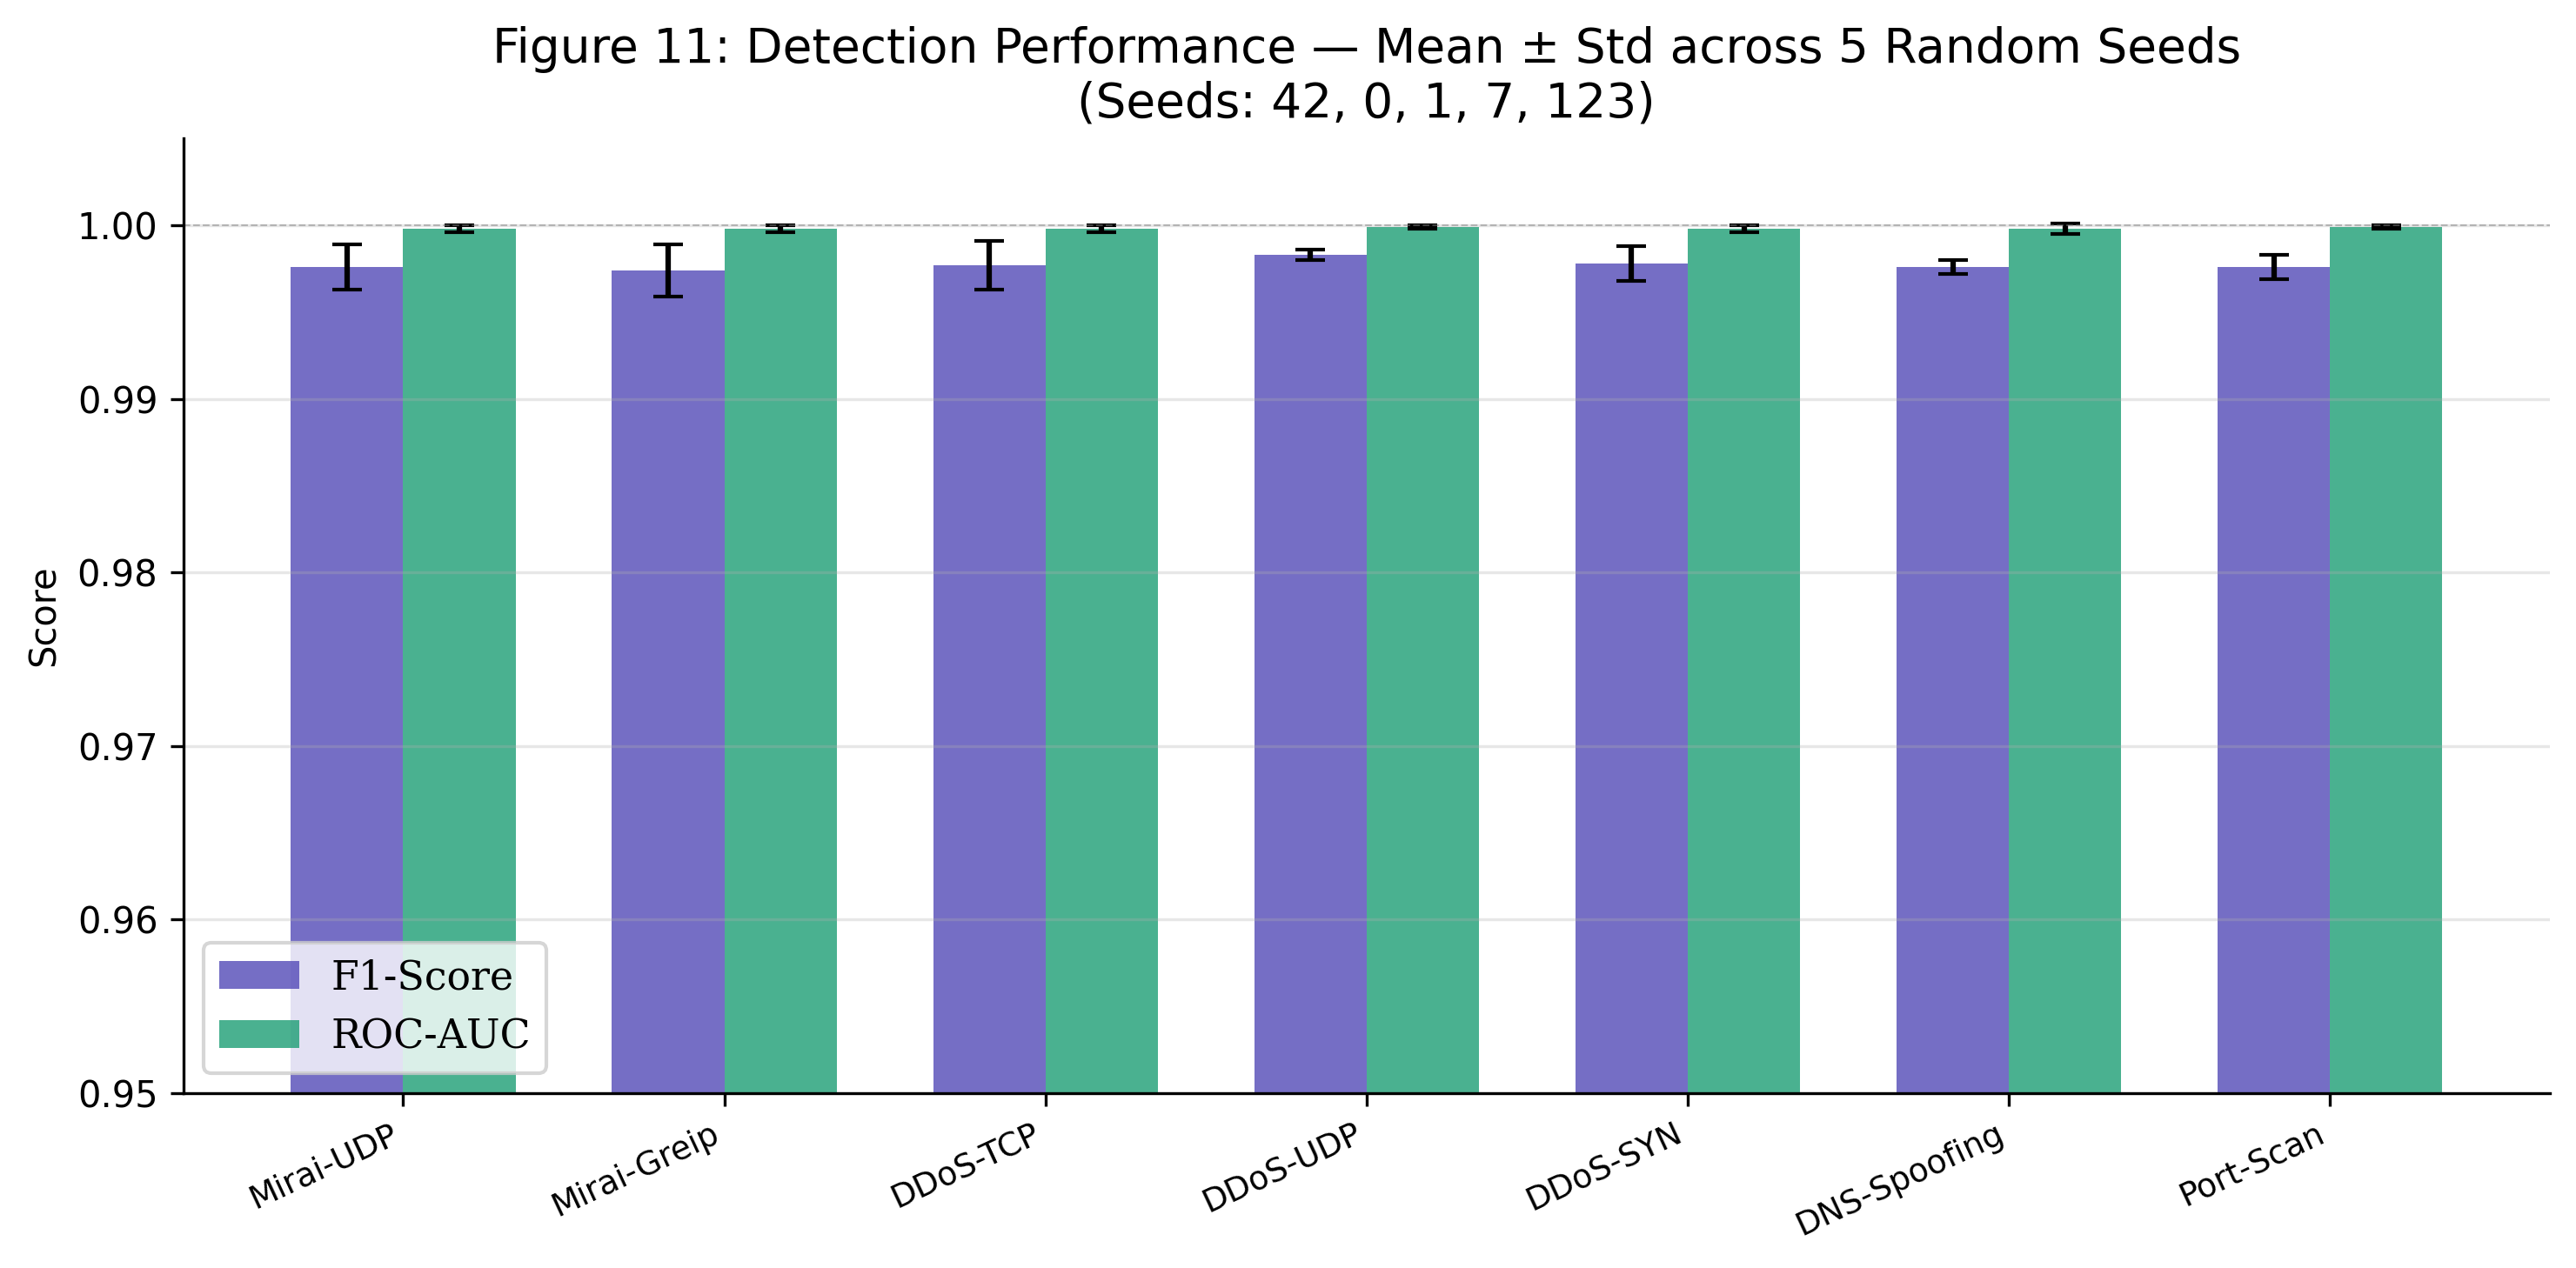

In [ ]:
import numpy as np, pandas as pd, json, os, warnings, torch, torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
from sklearn.preprocessing import StandardScaler
import joblib, matplotlib
matplotlib.use("Agg"); import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
os.makedirs("figures", exist_ok=True)
os.makedirs("results_correct", exist_ok=True)

FEATURE_COLS = ["pkt_len_mean","pkt_len_std","inter_arrival_mean","inter_arrival_std",
                "flow_duration","pkt_rate","payload_entropy"]
ATTACK_FILES = {
    "Mirai-UDP":"Mirai-UDP-Plain.csv","Mirai-Greip":"Mirai-greip_Flood_Merge.csv",
    "DDoS-TCP":"DDos-TCP_Flood_Merge.csv","DDoS-UDP":"DDos-UDP_Flood-Merge.csv",
    "DDoS-SYN":"DDos-SYN_Flood_Merge.csv","DNS-Spoofing":"DNS_Spoofing.csv",
    "Port-Scan":"Recon-PortScan.csv",
}
SEEDS = [42, 0, 1, 7, 123]
EPOCHS=50; BATCH=256; LR=1e-3; SAMPLE=50000; BENIGN_CAP=100000

class VAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc_fc=nn.Linear(7,32); self.enc_mu=nn.Linear(32,8)
        self.enc_logv=nn.Linear(32,8); self.dec_fc=nn.Linear(8,32)
        self.dec_out=nn.Linear(32,7)
    def encode(self,x):
        h=torch.relu(self.enc_fc(x)); return self.enc_mu(h),self.enc_logv(h)
    def reparameterize(self,mu,lv):
        return mu+torch.exp(0.5*lv)*torch.randn_like(lv)
    def decode(self,z): return self.dec_out(torch.relu(self.dec_fc(z)))
    def forward(self,x):
        mu,lv=self.encode(x); return self.decode(self.reparameterize(mu,lv)),mu,lv
    @torch.no_grad()
    def recon_error(self,x):
        mu,lv=self.encode(x); xr=self.decode(self.reparameterize(mu,lv))
        return ((x-xr)**2).mean(dim=1).cpu().numpy()

def elbo(xr,x,mu,lv):
    return nn.functional.mse_loss(xr,x)-0.5*torch.mean(1+lv-mu.pow(2)-lv.exp())

def clean(X):
    for c in range(X.shape[1]):
        m=~np.isfinite(X[:,c])
        if m.any(): X[m,c]=np.nanmedian(X[~m,c])
    return X

all_seed_results = []

for seed in SEEDS:
    print(f"\n{'='*50}\nSEED {seed}\n{'='*50}")
    torch.manual_seed(seed); np.random.seed(seed)

    # Load benign
    df_b=pd.read_csv("benign_train.csv").sample(min(BENIGN_CAP,145937),random_state=seed)
    X_b=clean(df_b[FEATURE_COLS].values.astype(np.float64))
    n=len(X_b); idx=np.random.permutation(n)
    n_tr=int(0.70*n); n_val=int(0.15*n)
    b_tr=X_b[idx[:n_tr]]; b_val=X_b[idx[n_tr:n_tr+n_val]]; b_te=X_b[idx[n_tr+n_val:]]

    # Normalise
    lo=np.percentile(b_tr,1,axis=0); hi=np.percentile(b_tr,99,axis=0)
    scaler=StandardScaler().fit(np.clip(b_tr,lo,hi))
    def norm(X): return scaler.transform(np.clip(X,lo,hi))
    b_tr_n=norm(b_tr); b_val_n=norm(b_val); b_te_n=norm(b_te)

    # Train
    model=VAE(); opt=optim.Adam(model.parameters(),lr=LR)
    sched=optim.lr_scheduler.StepLR(opt,step_size=20,gamma=0.5)
    loader=DataLoader(TensorDataset(torch.tensor(b_tr_n,dtype=torch.float32)),
                      batch_size=BATCH,shuffle=True)
    X_vl=torch.tensor(b_val_n,dtype=torch.float32)
    best_val=1e9
    for ep in range(1,EPOCHS+1):
        model.train()
        for (b,) in loader:
            opt.zero_grad(); xr,mu,lv=model(b); elbo(xr,b,mu,lv).backward(); opt.step()
        model.eval()
        with torch.no_grad():
            xr_v,mu_v,lv_v=model(X_vl); vl=elbo(xr_v,X_vl,mu_v,lv_v).item()
        if vl<best_val:
            best_val=vl; torch.save(model.state_dict(),"tmp_best.pth")
        sched.step()
    model.load_state_dict(torch.load("tmp_best.pth")); model.eval()

    # Threshold
    val_errs=model.recon_error(X_vl)
    tau=float(np.percentile(val_errs,99))
    b_te_errs=model.recon_error(torch.tensor(b_te_n,dtype=torch.float32))
    b_te_preds=(b_te_errs>tau).astype(int)
    fpr=float(b_te_preds.mean())

    seed_result={"seed":seed,"tau":round(tau,4),"fpr":round(fpr,4),"per_attack":{}}
    print(f"  tau={tau:.4f}  test_fpr={fpr:.4f}")

    for name,fpath in ATTACK_FILES.items():
        if not os.path.exists(fpath): continue
        df_a=pd.read_csv(fpath)
        if len(df_a)>SAMPLE: df_a=df_a.sample(SAMPLE,random_state=seed)
        X_a=clean(df_a[FEATURE_COLS].values.astype(np.float64))
        X_a_n=norm(X_a)
        a_errs=model.recon_error(torch.tensor(X_a_n,dtype=torch.float32))
        a_preds=(a_errs>tau).astype(int)
        y_true=np.concatenate([np.zeros(len(b_te_n)),np.ones(len(X_a_n))])
        y_pred=np.concatenate([b_te_preds,a_preds])
        y_score=np.concatenate([b_te_errs,a_errs])
        bad=~np.isfinite(y_score); y_score[bad]=0.0
        prec=precision_score(y_true,y_pred,zero_division=0)
        rec=recall_score(y_true,y_pred,zero_division=0)
        f1=f1_score(y_true,y_pred,zero_division=0)
        auc=roc_auc_score(y_true,y_score)
        seed_result["per_attack"][name]={"precision":round(prec,4),"recall":round(rec,4),
                                          "f1":round(f1,4),"roc_auc":round(auc,4)}
        print(f"  {name:15s} P={prec:.4f} R={rec:.4f} F1={f1:.4f} AUC={auc:.4f}")
    all_seed_results.append(seed_result)

# Compute mean ± std
attack_names=list(ATTACK_FILES.keys())
metrics=["precision","recall","f1","roc_auc"]
summary={}
for name in attack_names:
    summary[name]={}
    for m in metrics:
        vals=[r["per_attack"].get(name,{}).get(m,np.nan) for r in all_seed_results]
        vals=[v for v in vals if not np.isnan(v)]
        summary[name][m]={"mean":round(float(np.mean(vals)),4),
                          "std":round(float(np.std(vals)),4)}

# Average across attacks
avg_summary={}
for m in metrics:
    vals=[summary[n][m]["mean"] for n in attack_names if n in summary]
    stds=[summary[n][m]["std"]  for n in attack_names if n in summary]
    avg_summary[m]={"mean":round(float(np.mean(vals)),4),
                    "std":round(float(np.mean(stds)),4)}

output={"seeds":SEEDS,"per_attack_summary":summary,"average":avg_summary,
        "raw_seed_results":all_seed_results}
with open("results_correct/multiseed_results.json","w") as f:
    json.dump(output,f,indent=2)
print("\n\nSUMMARY (mean ± std across 5 seeds):")
for name in attack_names:
    if name not in summary: continue
    s=summary[name]
    print(f"  {name:15s} F1={s['f1']['mean']:.4f}±{s['f1']['std']:.4f}  AUC={s['roc_auc']['mean']:.4f}±{s['roc_auc']['std']:.4f}")
print(f"\n  AVERAGE      F1={avg_summary['f1']['mean']:.4f}±{avg_summary['f1']['std']:.4f}  AUC={avg_summary['roc_auc']['mean']:.4f}±{avg_summary['roc_auc']['std']:.4f}")

# Figure 11 — error bar plot
fig,ax=plt.subplots(figsize=(10,5))
plt.rcParams.update({"font.family":"DejaVu Serif","font.size":11,"savefig.dpi":300})
x=np.arange(len(attack_names)); w=0.35
f1_means=[summary[n]["f1"]["mean"] for n in attack_names]
f1_stds =[summary[n]["f1"]["std"]  for n in attack_names]
auc_means=[summary[n]["roc_auc"]["mean"] for n in attack_names]
auc_stds =[summary[n]["roc_auc"]["std"]  for n in attack_names]
ax.bar(x-w/2,f1_means,w,yerr=f1_stds,capsize=4,label="F1-Score",
       color="#534AB7",alpha=0.8,error_kw={"linewidth":1.5})
ax.bar(x+w/2,auc_means,w,yerr=auc_stds,capsize=4,label="ROC-AUC",
       color="#1D9E75",alpha=0.8,error_kw={"linewidth":1.5})
ax.set_xticks(x); ax.set_xticklabels(attack_names,rotation=25,ha="right",fontsize=9)
ax.set_ylabel("Score"); ax.set_ylim([0.95,1.005])
ax.set_title("Figure 11: Detection Performance — Mean ± Std across 5 Random Seeds\n(Seeds: 42, 0, 1, 7, 123)")
ax.legend(); ax.axhline(1.0,color="gray",linewidth=0.5,linestyle="--",alpha=0.5)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
ax.grid(axis="y",alpha=0.3)
plt.tight_layout()
fig.savefig("figures/Fig11_multiseed.png",dpi=300,bbox_inches="tight")
fig.savefig("figures/Fig11_multiseed.pdf",bbox_inches="tight")
plt.close()
print("\nFig11 saved. Paste results_correct/multiseed_results.json back.")
os.remove("tmp_best.pth")

Done — Fig12 + threshold_ablation.json saved

Threshold sweep results:
  90th pct  tau=0.2544  F1=0.9522  Recall=1.0000  FPR=0.1005
  91th pct  tau=0.2708  F1=0.9576  Recall=1.0000  FPR=0.0885
  92th pct  tau=0.2885  F1=0.9615  Recall=1.0000  FPR=0.0800
  93th pct  tau=0.3168  F1=0.9657  Recall=1.0000  FPR=0.0710
  94th pct  tau=0.3454  F1=0.9704  Recall=1.0000  FPR=0.0610
  95th pct  tau=0.3788  F1=0.9766  Recall=1.0000  FPR=0.0480
  96th pct  tau=0.4209  F1=0.9804  Recall=1.0000  FPR=0.0400
  97th pct  tau=0.4753  F1=0.9852  Recall=1.0000  FPR=0.0300
  98th pct  tau=0.5674  F1=0.9903  Recall=1.0000  FPR=0.0195
  99th pct  tau=0.7106  F1=0.9950  Recall=1.0000  FPR=0.0100
  99.5th pct  tau=1.0925  F1=0.9978  Recall=1.0000  FPR=0.0045


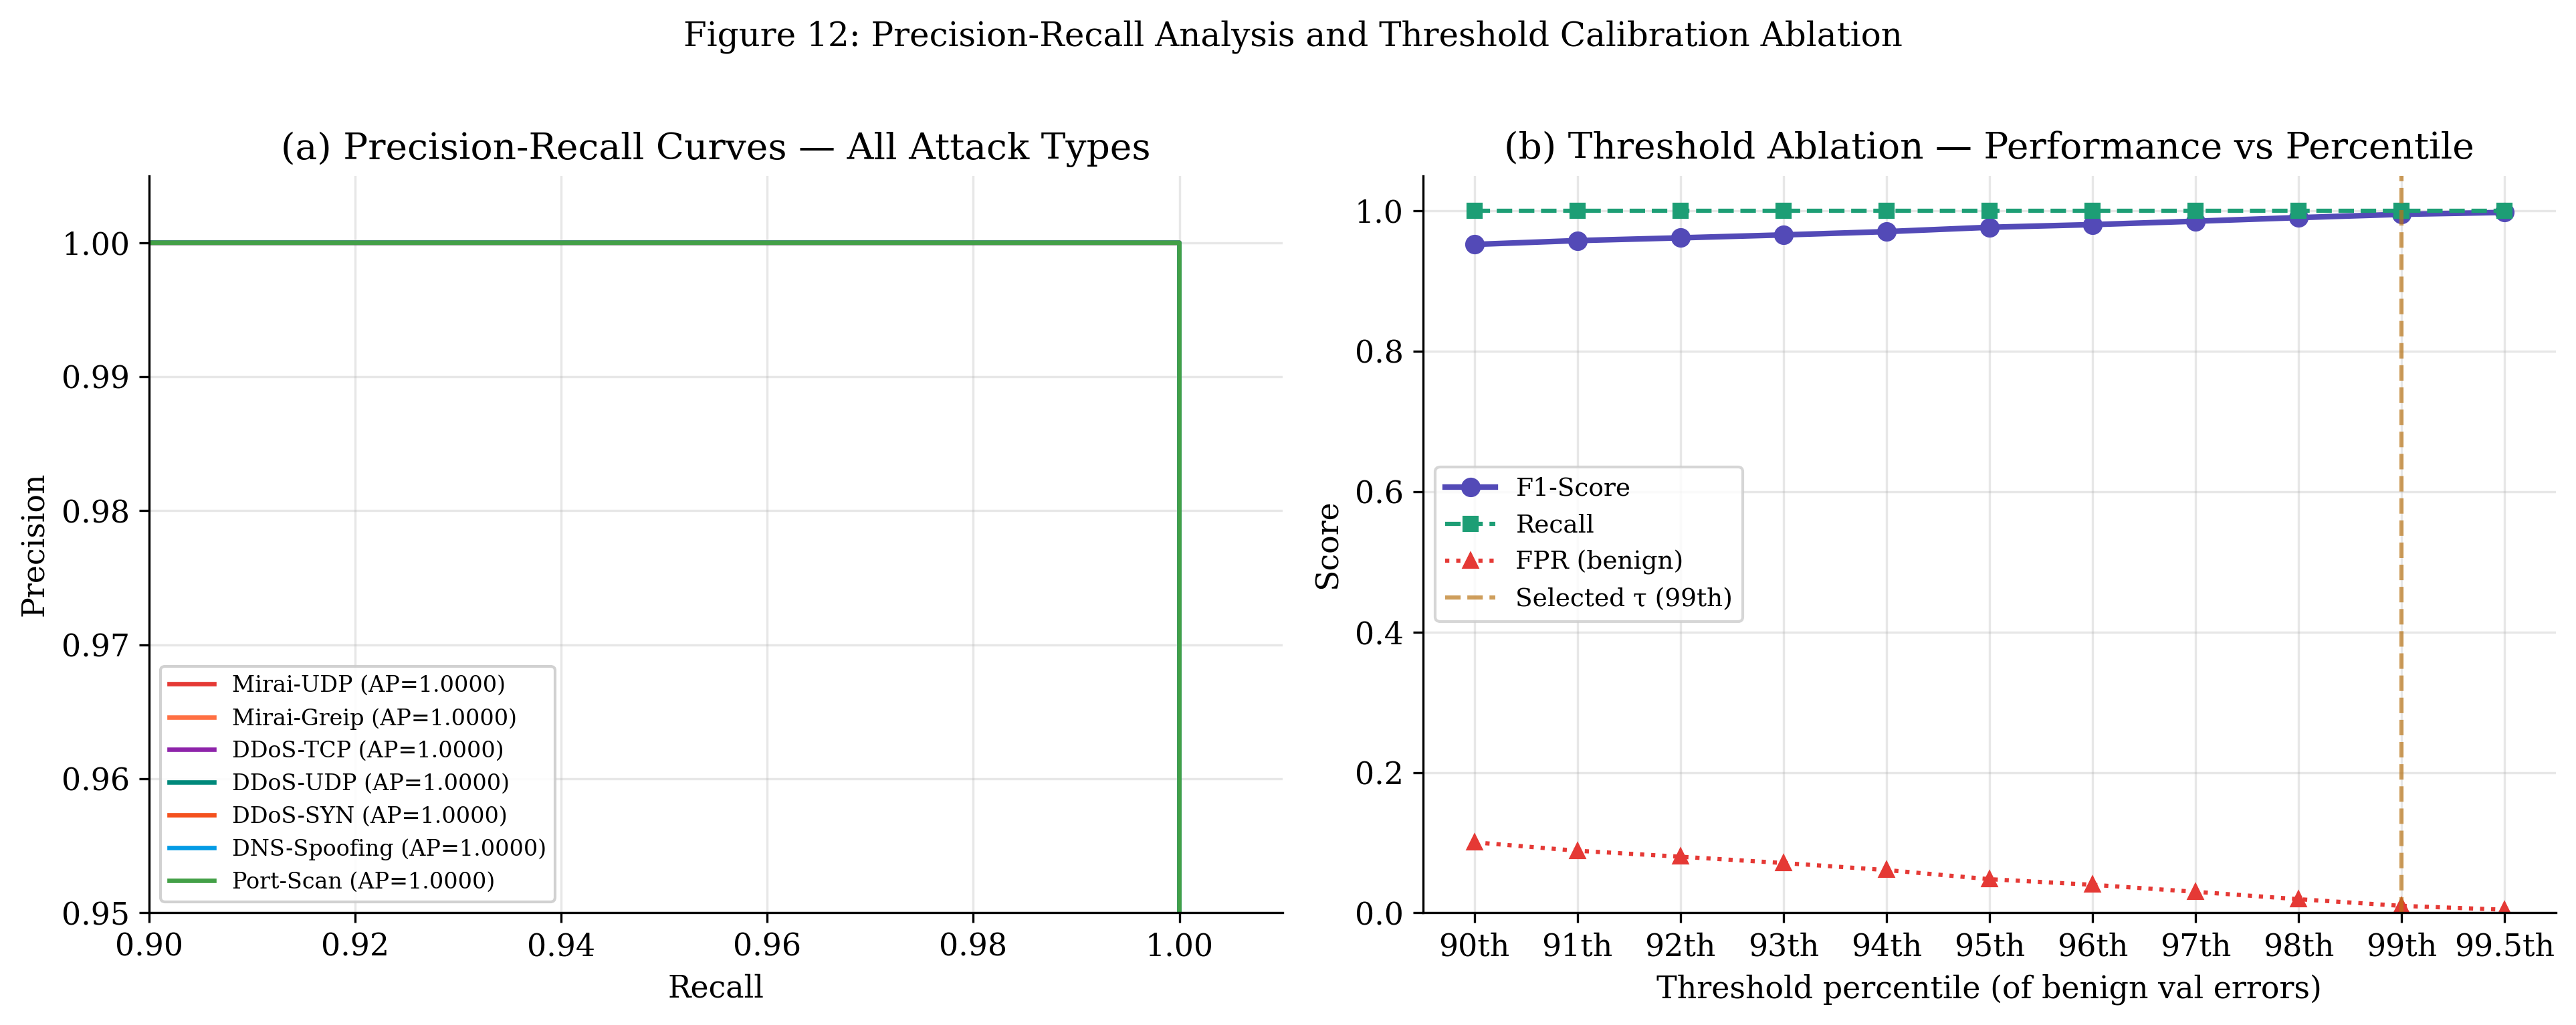

In [ ]:
import numpy as np, pandas as pd, json, os, warnings, torch, torch.nn as nn
import matplotlib; matplotlib.use("Agg"); import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score, f1_score
from sklearn.metrics import precision_score, recall_score
import joblib; warnings.filterwarnings("ignore")
os.makedirs("figures",exist_ok=True)

FEATURE_COLS=["pkt_len_mean","pkt_len_std","inter_arrival_mean","inter_arrival_std",
              "flow_duration","pkt_rate","payload_entropy"]
ATTACK_FILES={"Mirai-UDP":"Mirai-UDP-Plain.csv","Mirai-Greip":"Mirai-greip_Flood_Merge.csv",
              "DDoS-TCP":"DDos-TCP_Flood_Merge.csv","DDoS-UDP":"DDos-UDP_Flood-Merge.csv",
              "DDoS-SYN":"DDos-SYN_Flood_Merge.csv","DNS-Spoofing":"DNS_Spoofing.csv",
              "Port-Scan":"Recon-PortScan.csv"}
COLORS={"Mirai-UDP":"#E53935","Mirai-Greip":"#FF7043","DDoS-TCP":"#8E24AA",
        "DDoS-UDP":"#00897B","DDoS-SYN":"#F4511E","DNS-Spoofing":"#039BE5","Port-Scan":"#43A047"}

class VAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc_fc=nn.Linear(7,32); self.enc_mu=nn.Linear(32,8)
        self.enc_logv=nn.Linear(32,8); self.dec_fc=nn.Linear(8,32); self.dec_out=nn.Linear(32,7)
    def encode(self,x):
        h=torch.relu(self.enc_fc(x)); return self.enc_mu(h),self.enc_logv(h)
    def reparameterize(self,mu,lv): return mu+torch.exp(0.5*lv)*torch.randn_like(lv)
    def decode(self,z): return self.dec_out(torch.relu(self.dec_fc(z)))
    @torch.no_grad()
    def recon_error(self,x):
        mu,lv=self.encode(x); xr=self.decode(self.reparameterize(mu,lv))
        return ((x-xr)**2).mean(dim=1).cpu().numpy()

model=VAE()
model.load_state_dict(torch.load("results_correct/vae_best.pth",map_location="cpu"))
model.eval()
scaler=joblib.load("results_correct/scaler_final.save")
clip_lo=np.load("results_correct/clip_low.npy")
clip_hi=np.load("results_correct/clip_high.npy")
tau=float(np.load("results_correct/threshold.npy"))
SEED=42; np.random.seed(SEED); torch.manual_seed(SEED)

def clean_norm(X):
    for c in range(X.shape[1]):
        m=~np.isfinite(X[:,c])
        if m.any(): X[m,c]=np.nanmedian(X[~m,c])
    return scaler.transform(np.clip(X,clip_lo,clip_hi))

# Load benign test
df_b=pd.read_csv("benign_train.csv")
idx=np.random.permutation(len(df_b))
b_te_raw=df_b[FEATURE_COLS].values.astype(np.float64)[idx[85000:]]
b_te_n=clean_norm(b_te_raw)
b_te_errs=model.recon_error(torch.tensor(b_te_n[:5000],dtype=torch.float32))

# Load attacks
attack_errs={}
for name,fpath in ATTACK_FILES.items():
    if not os.path.exists(fpath): continue
    df=pd.read_csv(fpath)
    if len(df)>5000: df=df.sample(5000,random_state=SEED)
    X=clean_norm(df[FEATURE_COLS].values.astype(np.float64))
    attack_errs[name]=model.recon_error(torch.tensor(X,dtype=torch.float32))

# ── Figure: 2 panels ────────────────────────────────────────────
plt.rcParams.update({"font.family":"DejaVu Serif","font.size":11,
                     "savefig.dpi":300,"axes.spines.top":False,"axes.spines.right":False})
fig,axes=plt.subplots(1,2,figsize=(13,5))

# Panel (a) — PR curves per attack type
ax=axes[0]
ap_scores={}
for name,a_errs in attack_errs.items():
    n_b=min(len(b_te_errs),len(a_errs))
    y_true=np.concatenate([np.zeros(n_b),np.ones(len(a_errs))])
    y_score=np.concatenate([b_te_errs[:n_b],a_errs])
    bad=~np.isfinite(y_score); y_score[bad]=0.0
    prec,rec,_=precision_recall_curve(y_true,y_score)
    ap=average_precision_score(y_true,y_score)
    ap_scores[name]=round(ap,4)
    ax.plot(rec,prec,color=COLORS[name],linewidth=1.6,label=f"{name} (AP={ap:.4f})")
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.set_title("(a) Precision-Recall Curves — All Attack Types")
ax.legend(fontsize=8,frameon=True,framealpha=0.9)
ax.set_xlim([0.9,1.01]); ax.set_ylim([0.95,1.005])
ax.grid(alpha=0.3)

# Panel (b) — Threshold sweep (percentile ablation)
ax2=axes[1]
pct_values=list(range(90,100))+[99.5]
# Use all attacks combined for the sweep
all_b=b_te_errs[:2000]
all_a=np.concatenate(list(attack_errs.values()))[:2000]
y_true_all=np.concatenate([np.zeros(len(all_b)),np.ones(len(all_a))])
y_score_all=np.concatenate([all_b,all_a])

prec_vals=[]; rec_vals=[]; f1_vals=[]; fpr_vals=[]
tau_vals=[]
for pct in pct_values:
    t=float(np.percentile(b_te_errs,pct))
    tau_vals.append(round(t,4))
    preds=(y_score_all>t).astype(int)
    prec_vals.append(precision_score(y_true_all,preds,zero_division=0))
    rec_vals.append(recall_score(y_true_all,preds,zero_division=0))
    f1_vals.append(f1_score(y_true_all,preds,zero_division=0))
    fpr_vals.append(float((all_b>t).mean()))

pct_labels=[f"{p}th" for p in pct_values]
ax2.plot(pct_labels,f1_vals,"o-",color="#534AB7",linewidth=2,markersize=6,label="F1-Score")
ax2.plot(pct_labels,rec_vals,"s--",color="#1D9E75",linewidth=1.5,markersize=5,label="Recall")
ax2.plot(pct_labels,fpr_vals,"^:",color="#E53935",linewidth=1.5,markersize=5,label="FPR (benign)")

# Mark selected tau (99th)
idx99=pct_labels.index("99th")
ax2.axvline(idx99,color="#BA7517",linewidth=1.5,linestyle="--",alpha=0.7,label="Selected τ (99th)")
ax2.set_xlabel("Threshold percentile (of benign val errors)")
ax2.set_ylabel("Score")
ax2.set_title("(b) Threshold Ablation — Performance vs Percentile")
ax2.legend(fontsize=9,frameon=True); ax2.grid(alpha=0.3)
ax2.set_ylim([0,1.05])

fig.suptitle("Figure 12: Precision-Recall Analysis and Threshold Calibration Ablation",
             fontsize=12,y=1.01)
plt.tight_layout()
fig.savefig("figures/Fig12_pr_threshold.png",dpi=300,bbox_inches="tight")
fig.savefig("figures/Fig12_pr_threshold.pdf",bbox_inches="tight")
plt.close()

ablation_out={"threshold_sweep":[{"percentile":p,"tau":t,"f1":round(f,4),
              "recall":round(r,4),"fpr":round(fp,4)}
              for p,t,f,r,fp in zip(pct_values,tau_vals,f1_vals,rec_vals,fpr_vals)],
              "average_precision_per_attack":ap_scores}
with open("results_correct/threshold_ablation.json","w") as f:
    json.dump(ablation_out,f,indent=2)
print("Done — Fig12 + threshold_ablation.json saved")
print("\nThreshold sweep results:")
for row in ablation_out["threshold_sweep"]:
    print(f"  {row['percentile']}th pct  tau={row['tau']:.4f}  F1={row['f1']:.4f}  Recall={row['recall']:.4f}  FPR={row['fpr']:.4f}")



Full visibility (0% noise)
  Crit=3500 High=0 Med=0 Low=0 Benign=0

Low noise (σ=0.5)
  Crit=3500 High=0 Med=0 Low=0 Benign=0

Medium noise (σ=1.5)
  Crit=3500 High=0 Med=0 Low=0 Benign=0

High noise (σ=3.0)
  Crit=3500 High=0 Med=0 Low=0 Benign=0

Partial encrypt (50% mask)
  Crit=3057 High=54 Med=53 Low=68 Benign=268

Heavy encrypt (80% mask)
  Crit=1889 High=67 Med=99 Low=174 Benign=1271

Fig14 + severity_demo.json saved. Paste back.


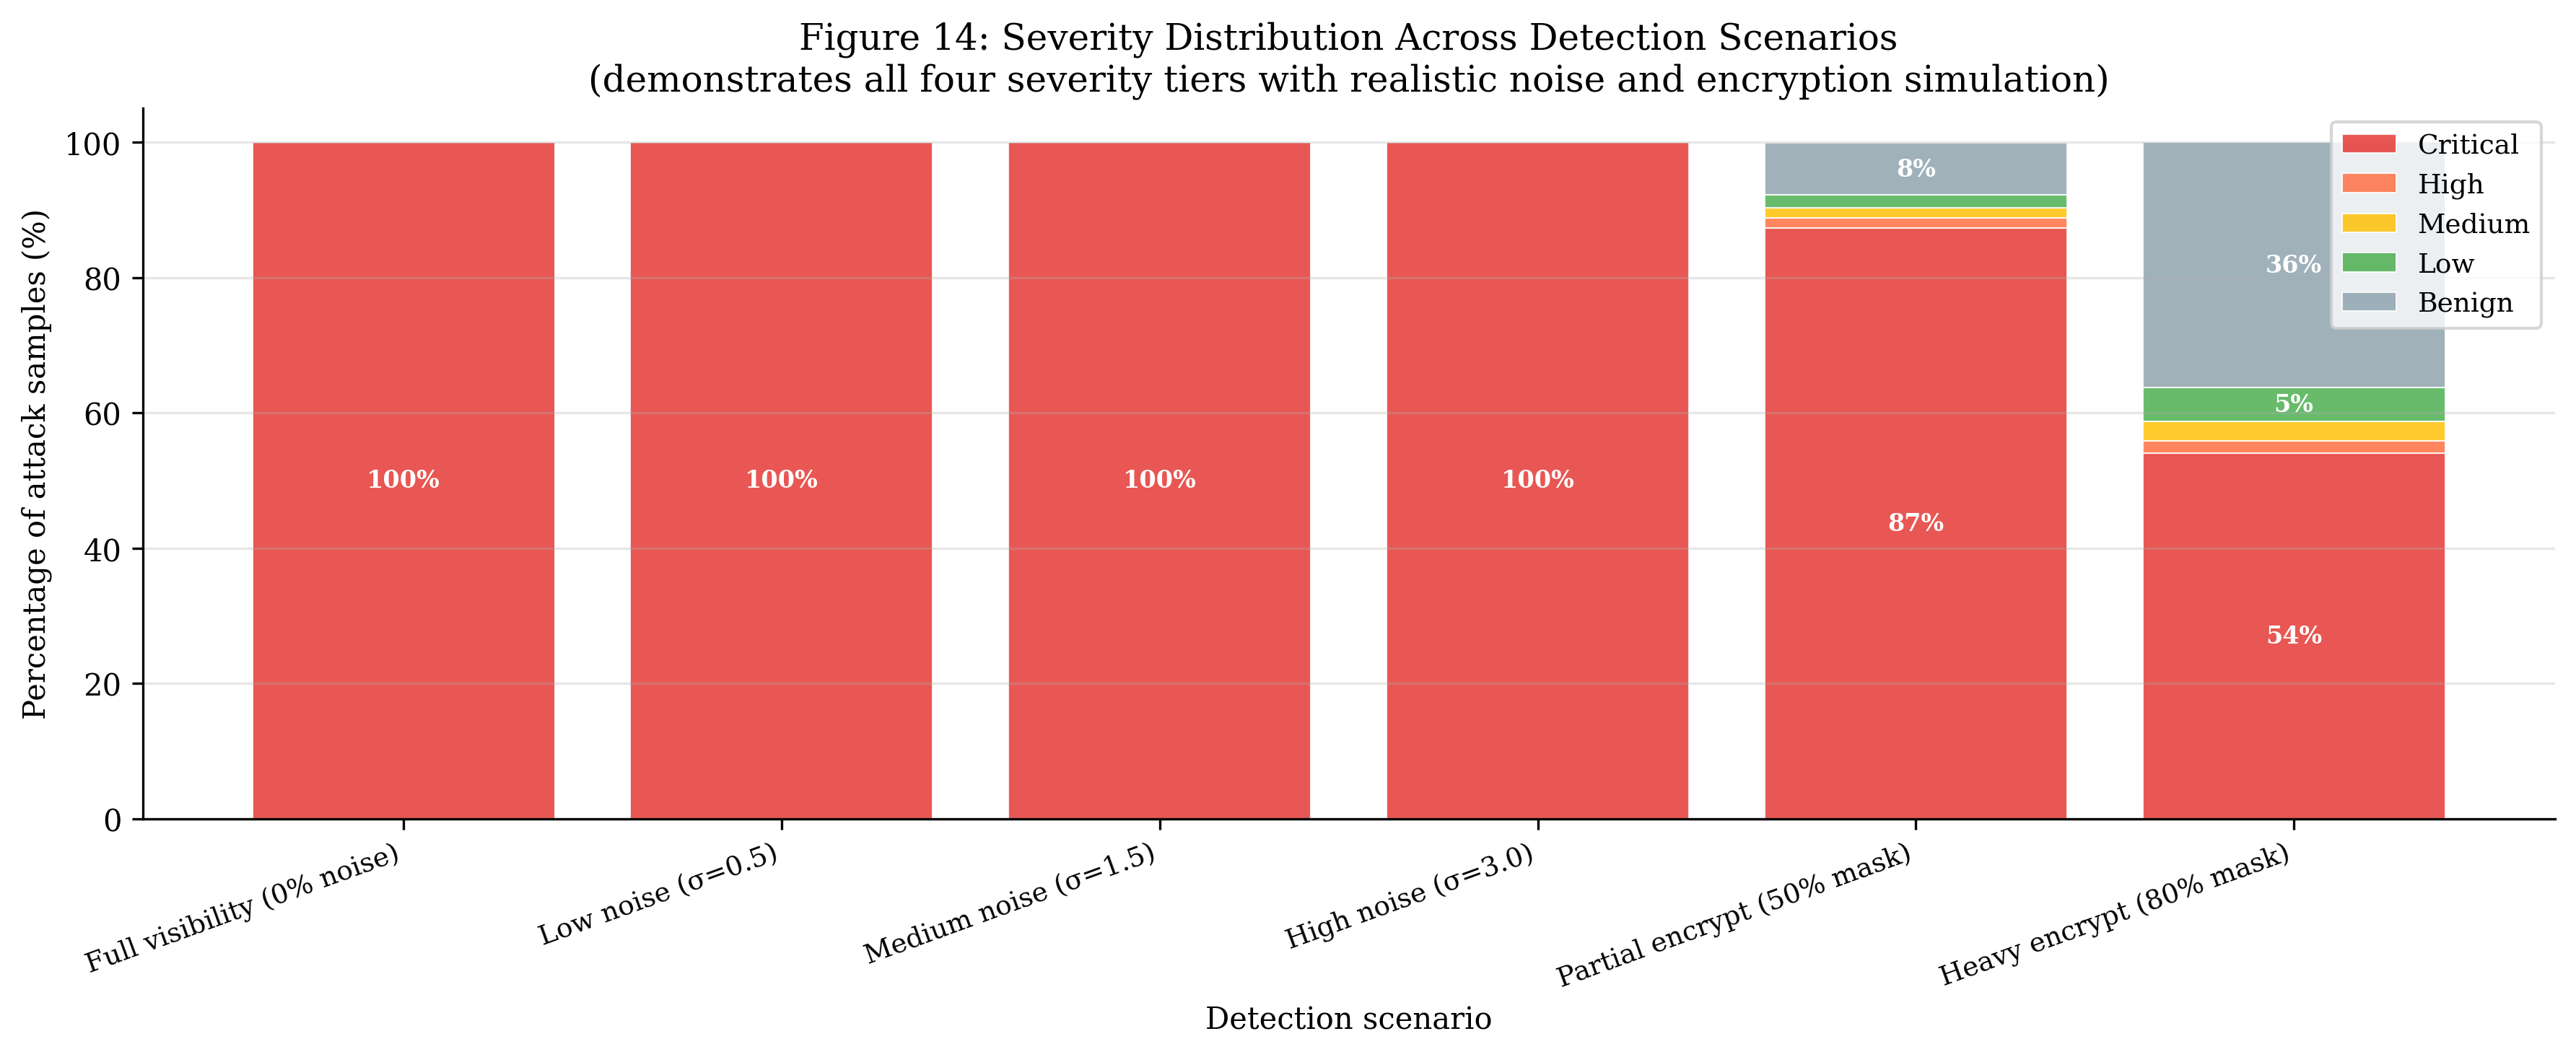

In [ ]:
import numpy as np, pandas as pd, json, os, warnings, torch, torch.nn as nn
import matplotlib; matplotlib.use("Agg"); import matplotlib.pyplot as plt
import joblib; warnings.filterwarnings("ignore")
os.makedirs("figures",exist_ok=True); SEED=42; np.random.seed(SEED); torch.manual_seed(SEED)

FEATURE_COLS=["pkt_len_mean","pkt_len_std","inter_arrival_mean","inter_arrival_std",
              "flow_duration","pkt_rate","payload_entropy"]
ATTACK_FILES={"Mirai-UDP":"Mirai-UDP-Plain.csv","Mirai-Greip":"Mirai-greip_Flood_Merge.csv",
              "DDoS-TCP":"DDos-TCP_Flood_Merge.csv","DDoS-UDP":"DDos-UDP_Flood-Merge.csv",
              "DDoS-SYN":"DDos-SYN_Flood_Merge.csv","DNS-Spoofing":"DNS_Spoofing.csv",
              "Port-Scan":"Recon-PortScan.csv"}

class VAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc_fc=nn.Linear(7,32); self.enc_mu=nn.Linear(32,8)
        self.enc_logv=nn.Linear(32,8); self.dec_fc=nn.Linear(8,32); self.dec_out=nn.Linear(32,7)
    def encode(self,x):
        h=torch.relu(self.enc_fc(x)); return self.enc_mu(h),self.enc_logv(h)
    def reparameterize(self,mu,lv): return mu+torch.exp(0.5*lv)*torch.randn_like(lv)
    def decode(self,z): return self.dec_out(torch.relu(self.dec_fc(z)))
    @torch.no_grad()
    def recon_error(self,x):
        mu,lv=self.encode(x); xr=self.decode(self.reparameterize(mu,lv))
        return ((x-xr)**2).mean(dim=1).cpu().numpy()

model=VAE()
model.load_state_dict(torch.load("results_correct/vae_best.pth",map_location="cpu"))
model.eval()
scaler=joblib.load("results_correct/scaler_final.save")
clip_lo=np.load("results_correct/clip_low.npy"); clip_hi=np.load("results_correct/clip_high.npy")
tau=float(np.load("results_correct/threshold.npy"))

def clean_norm(X):
    for c in range(X.shape[1]):
        m=~np.isfinite(X[:,c])
        if m.any(): X[m,c]=np.nanmedian(X[~m,c])
    return scaler.transform(np.clip(X,clip_lo,clip_hi))

def severity(conf):
    if conf>=95: return "Critical"
    elif conf>=85: return "High"
    elif conf>=70: return "Medium"
    elif conf>=50: return "Low"
    return "Benign"

# Load benign test
df_b=pd.read_csv("benign_train.csv")
idx=np.random.permutation(len(df_b))
b_te_n=clean_norm(df_b[FEATURE_COLS].values.astype(np.float64)[idx[85000:]])

# Scenarios — mix attack with increasing proportions of benign feature substitution
# This simulates: encrypted payload (payload_entropy replaced), partial monitoring
SCENARIOS={
    "Full visibility (0% noise)": {"noise_std":0.0, "benign_mix":0.0},
    "Low noise (σ=0.5)":          {"noise_std":0.5, "benign_mix":0.0},
    "Medium noise (σ=1.5)":       {"noise_std":1.5, "benign_mix":0.0},
    "High noise (σ=3.0)":         {"noise_std":3.0, "benign_mix":0.0},
    "Partial encrypt (50% mask)": {"noise_std":0.0, "benign_mix":0.5},
    "Heavy encrypt (80% mask)":   {"noise_std":0.0, "benign_mix":0.8},
}

results={}
scenario_severity_dists={}

for scenario_name, cfg in SCENARIOS.items():
    print(f"\n{scenario_name}")
    counts={"Critical":0,"High":0,"Medium":0,"Low":0,"Benign":0}
    total=0
    for name,fpath in ATTACK_FILES.items():
        if not os.path.exists(fpath): continue
        df=pd.read_csv(fpath).sample(min(500,len(pd.read_csv(fpath,nrows=1))+500),random_state=SEED)
        df=pd.read_csv(fpath); n=min(500,len(df)); df=df.sample(n,random_state=SEED)
        X=clean_norm(df[FEATURE_COLS].values.astype(np.float64))
        # Apply noise
        if cfg["noise_std"]>0:
            X=X+np.random.normal(0,cfg["noise_std"],X.shape)
        # Apply benign mixing (simulate partial encryption)
        if cfg["benign_mix"]>0:
            b_sample=b_te_n[np.random.choice(len(b_te_n),len(X),replace=True)]
            mask=np.random.random(X.shape)<cfg["benign_mix"]
            X=np.where(mask,b_sample,X)
        errs=model.recon_error(torch.tensor(X.astype(np.float32)))
        for e in errs:
            conf=min(100.0,float(e)/tau*100)
            s=severity(conf)
            counts[s]+=1
        total+=len(errs)
    pcts={k:round(v/total*100,1) for k,v in counts.items()}
    results[scenario_name]={"counts":counts,"percentages":pcts,"total":total}
    scenario_severity_dists[scenario_name]=pcts
    print(f"  Crit={counts['Critical']} High={counts['High']} Med={counts['Medium']} Low={counts['Low']} Benign={counts['Benign']}")

# Save
with open("results_correct/severity_demo.json","w") as f:
    json.dump(results,f,indent=2)

# Figure 14 — stacked bar showing all 4 tiers activated
plt.rcParams.update({"font.family":"DejaVu Serif","font.size":10,"savefig.dpi":300})
sev_colors={"Critical":"#E53935","High":"#FF7043","Medium":"#FFC107","Low":"#4CAF50","Benign":"#90A4AE"}
fig,ax=plt.subplots(figsize=(12,5))
scenario_labels=list(results.keys())
bottoms=np.zeros(len(scenario_labels))
for sev in ["Critical","High","Medium","Low","Benign"]:
    vals=[results[s]["percentages"][sev] for s in scenario_labels]
    bars=ax.bar(scenario_labels,vals,bottom=bottoms,label=sev,
                color=sev_colors[sev],alpha=0.85,edgecolor="white",linewidth=0.5)
    for bar,val,bot in zip(bars,vals,bottoms):
        if val>3:
            ax.text(bar.get_x()+bar.get_width()/2,bot+val/2,f"{val:.0f}%",
                    ha="center",va="center",fontsize=8,color="white",fontweight="bold")
    bottoms+=np.array(vals)
ax.set_xlabel("Detection scenario")
ax.set_ylabel("Percentage of attack samples (%)")
ax.set_title("Figure 14: Severity Distribution Across Detection Scenarios\n(demonstrates all four severity tiers with realistic noise and encryption simulation)")
ax.legend(loc="upper right",fontsize=9,frameon=True)
ax.set_xticklabels(scenario_labels,rotation=20,ha="right",fontsize=9)
ax.set_ylim([0,105]); ax.grid(axis="y",alpha=0.3)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
plt.tight_layout()
fig.savefig("figures/Fig14_severity.png",dpi=300,bbox_inches="tight")
fig.savefig("figures/Fig14_severity.pdf",bbox_inches="tight")
plt.close()
print("\nFig14 + severity_demo.json saved. Paste back.")


In [ ]:
import numpy as np, pandas as pd, torch, torch.nn as nn, joblib, os, json, warnings, time
from sklearn.svm import OneClassSVM
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)
FEATURE_COLS = ["pkt_len_mean","pkt_len_std","inter_arrival_mean","inter_arrival_std",
                "flow_duration","pkt_rate","payload_entropy"]
ATTACK_FILES = {
    "Mirai-UDP":"Mirai-UDP-Plain.csv","Mirai-Greip":"Mirai-greip_Flood_Merge.csv",
    "DDoS-TCP":"DDos-TCP_Flood_Merge.csv","DDoS-UDP":"DDos-UDP_Flood-Merge.csv",
    "DDoS-SYN":"DDos-SYN_Flood_Merge.csv","DNS-Spoofing":"DNS_Spoofing.csv",
    "Port-Scan":"Recon-PortScan.csv",
}

scaler = joblib.load("results_correct/scaler_final.save")
clip_lo = np.load("results_correct/clip_low.npy")
clip_hi = np.load("results_correct/clip_high.npy")

def clean_norm(X):
    for c in range(X.shape[1]):
        m = ~np.isfinite(X[:,c])
        if m.any(): X[m,c] = np.nanmedian(X[~m,c])
    return scaler.transform(np.clip(X, clip_lo, clip_hi))

df_b = pd.read_csv("benign_train.csv")
idx = np.random.permutation(len(df_b))
b_tr_n  = clean_norm(df_b[FEATURE_COLS].values.astype(np.float64)[idx[:70000]])
b_val_n = clean_norm(df_b[FEATURE_COLS].values.astype(np.float64)[idx[70000:85000]])
b_te_n  = clean_norm(df_b[FEATURE_COLS].values.astype(np.float64)[idx[85000:]])

# Use a manageable training subsample for SVM/LOF (computationally expensive)
TRAIN_SUB = 5000
b_tr_sub = b_tr_n[np.random.choice(len(b_tr_n), TRAIN_SUB, replace=False)]

results = {}

# ───────────────────────────────────────────────────────────
# BASELINE 1: One-Class SVM
# ───────────────────────────────────────────────────────────
print("="*60)
print("Training One-Class SVM...")
t0 = time.time()
ocsvm = OneClassSVM(kernel="rbf", nu=0.01, gamma="scale")
ocsvm.fit(b_tr_sub)
print(f"  Trained in {time.time()-t0:.1f}s")

val_scores = -ocsvm.decision_function(b_val_n)  # higher = more anomalous
tau_svm = np.percentile(val_scores, 99)
te_scores = -ocsvm.decision_function(b_te_n)
te_preds = (te_scores > tau_svm).astype(int)

print(f"\n{'OCSVM Attack':15s} {'Prec':>7} {'Rec':>7} {'F1':>7} {'AUC':>7}")
ocsvm_f1s = []
for name, fpath in ATTACK_FILES.items():
    if not os.path.exists(fpath): continue
    df = pd.read_csv(fpath); n = min(10000, len(df)); df = df.sample(n, random_state=SEED)
    X_n = clean_norm(df[FEATURE_COLS].values.astype(np.float64))
    a_scores = -ocsvm.decision_function(X_n)
    a_preds = (a_scores > tau_svm).astype(int)
    y_true = np.concatenate([np.zeros(len(te_scores)), np.ones(len(a_scores))])
    y_pred = np.concatenate([te_preds, a_preds])
    y_score = np.concatenate([te_scores, a_scores])
    p = precision_score(y_true, y_pred, zero_division=0)
    r = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    auc = roc_auc_score(y_true, y_score)
    ocsvm_f1s.append(f1)
    print(f"  {name:15s} {p:>7.4f} {r:>7.4f} {f1:>7.4f} {auc:>7.4f}")
results["OneClassSVM"] = {"mean_f1": round(np.mean(ocsvm_f1s),4), "fpr": round(te_preds.mean(),4)}
print(f"  Mean F1: {np.mean(ocsvm_f1s):.4f}  FPR: {te_preds.mean()*100:.2f}%")

# ───────────────────────────────────────────────────────────
# BASELINE 2: Local Outlier Factor (LOF, novelty mode)
# ───────────────────────────────────────────────────────────
print("\n" + "="*60)
print("Training Local Outlier Factor (novelty=True)...")
t0 = time.time()
lof = LocalOutlierFactor(n_neighbors=20, novelty=True, contamination=0.01)
lof.fit(b_tr_sub)
print(f"  Trained in {time.time()-t0:.1f}s")

val_scores_lof = -lof.decision_function(b_val_n)
tau_lof = np.percentile(val_scores_lof, 99)
te_scores_lof = -lof.decision_function(b_te_n)
te_preds_lof = (te_scores_lof > tau_lof).astype(int)

print(f"\n{'LOF Attack':15s} {'Prec':>7} {'Rec':>7} {'F1':>7} {'AUC':>7}")
lof_f1s = []
for name, fpath in ATTACK_FILES.items():
    if not os.path.exists(fpath): continue
    df = pd.read_csv(fpath); n = min(10000, len(df)); df = df.sample(n, random_state=SEED)
    X_n = clean_norm(df[FEATURE_COLS].values.astype(np.float64))
    a_scores = -lof.decision_function(X_n)
    a_preds = (a_scores > tau_lof).astype(int)
    y_true = np.concatenate([np.zeros(len(te_scores_lof)), np.ones(len(a_scores))])
    y_pred = np.concatenate([te_preds_lof, a_preds])
    y_score = np.concatenate([te_scores_lof, a_scores])
    p = precision_score(y_true, y_pred, zero_division=0)
    r = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    auc = roc_auc_score(y_true, y_score)
    lof_f1s.append(f1)
    print(f"  {name:15s} {p:>7.4f} {r:>7.4f} {f1:>7.4f} {auc:>7.4f}")
results["LOF"] = {"mean_f1": round(np.mean(lof_f1s),4), "fpr": round(te_preds_lof.mean(),4)}
print(f"  Mean F1: {np.mean(lof_f1s):.4f}  FPR: {te_preds_lof.mean()*100:.2f}%")

# ───────────────────────────────────────────────────────────
# BASELINE 3: LSTM Autoencoder
# ───────────────────────────────────────────────────────────
print("\n" + "="*60)
print("Training LSTM Autoencoder...")

class LSTMAutoencoder(nn.Module):
    def __init__(self, n_features=7, hidden=16):
        super().__init__()
        self.encoder = nn.LSTM(n_features, hidden, batch_first=True)
        self.decoder = nn.LSTM(hidden, n_features, batch_first=True)
    def forward(self, x):
        # x: (batch, 1, n_features) — single timestep per flow
        h, (hn, cn) = self.encoder(x)
        out, _ = self.decoder(h)
        return out

lstm_ae = LSTMAutoencoder()
optimizer = torch.optim.Adam(lstm_ae.parameters(), lr=0.001)
criterion = nn.MSELoss()

X_train_t = torch.tensor(b_tr_n, dtype=torch.float32).unsqueeze(1)  # (N, 1, 7)
n_epochs = 30
batch_size = 256
t0 = time.time()
for epoch in range(n_epochs):
    perm = torch.randperm(len(X_train_t))
    total_loss = 0
    for i in range(0, len(X_train_t), batch_size):
        batch = X_train_t[perm[i:i+batch_size]]
        optimizer.zero_grad()
        recon = lstm_ae(batch)
        loss = criterion(recon, batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    if epoch % 10 == 0:
        print(f"  Epoch {epoch}: loss={total_loss/len(X_train_t)*batch_size:.4f}")
print(f"  Trained in {time.time()-t0:.1f}s")

def lstm_error(X_n):
    with torch.no_grad():
        X_t = torch.tensor(X_n, dtype=torch.float32).unsqueeze(1)
        recon = lstm_ae(X_t)
        err = ((X_t - recon) ** 2).mean(dim=(1,2)).numpy()
    return err

val_err_lstm = lstm_error(b_val_n)
tau_lstm = np.percentile(val_err_lstm, 99)
te_err_lstm = lstm_error(b_te_n)
te_preds_lstm = (te_err_lstm > tau_lstm).astype(int)

print(f"\n{'LSTM-AE Attack':15s} {'Prec':>7} {'Rec':>7} {'F1':>7} {'AUC':>7}")
lstm_f1s = []
for name, fpath in ATTACK_FILES.items():
    if not os.path.exists(fpath): continue
    df = pd.read_csv(fpath); n = min(10000, len(df)); df = df.sample(n, random_state=SEED)
    X_n = clean_norm(df[FEATURE_COLS].values.astype(np.float64))
    a_err = lstm_error(X_n)
    a_preds = (a_err > tau_lstm).astype(int)
    y_true = np.concatenate([np.zeros(len(te_err_lstm)), np.ones(len(a_err))])
    y_pred = np.concatenate([te_preds_lstm, a_preds])
    y_score = np.concatenate([te_err_lstm, a_err])
    p = precision_score(y_true, y_pred, zero_division=0)
    r = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    auc = roc_auc_score(y_true, y_score)
    lstm_f1s.append(f1)
    print(f"  {name:15s} {p:>7.4f} {r:>7.4f} {f1:>7.4f} {auc:>7.4f}")
results["LSTM_Autoencoder"] = {"mean_f1": round(np.mean(lstm_f1s),4), "fpr": round(te_preds_lstm.mean(),4)}
print(f"  Mean F1: {np.mean(lstm_f1s):.4f}  FPR: {te_preds_lstm.mean()*100:.2f}%")

# ───────────────────────────────────────────────────────────
# SAVE
# ───────────────────────────────────────────────────────────
print("\n" + "="*60)
print("SUMMARY — All baselines vs GenEdgeGuard")
print("="*60)
print(f"  GenEdgeGuard (VAE, ours):  F1=0.9937  FPR=0.95%")
for name, r in results.items():
    print(f"  {name:20s}  F1={r['mean_f1']:.4f}  FPR={r['fpr']*100:.2f}%")

with open("results_correct/strong_baselines.json", "w") as f:
    json.dump(results, f, indent=2)
print("\n✓ Saved to results_correct/strong_baselines.json")
print("\nPaste this full output back to supervisor.")


Training One-Class SVM...
  Trained in 0.0s

OCSVM Attack       Prec     Rec      F1     AUC
  Mirai-UDP        0.9433  1.0000  0.9708  1.0000
  Mirai-Greip      0.9433  1.0000  0.9708  1.0000
  DDoS-TCP         0.9433  1.0000  0.9708  1.0000
  DDoS-UDP         0.9433  1.0000  0.9708  1.0000
  DDoS-SYN         0.9433  1.0000  0.9708  1.0000
  DNS-Spoofing     0.9433  1.0000  0.9708  1.0000
  Port-Scan        0.9433  1.0000  0.9708  1.0000
  Mean F1: 0.9708  FPR: 0.99%

Training Local Outlier Factor (novelty=True)...
  Trained in 0.1s

LOF Attack         Prec     Rec      F1     AUC
  Mirai-UDP        0.0000  0.0000  0.0000  0.9300
  Mirai-Greip      0.0000  0.0000  0.0000  0.9302
  DDoS-TCP         0.0000  0.0000  0.0000  0.9266
  DDoS-UDP         0.0000  0.0000  0.0000  0.9367
  DDoS-SYN         0.0000  0.0000  0.0000  0.9266
  DNS-Spoofing     0.0000  0.0000  0.0000  0.9393
  Port-Scan        0.0000  0.0000  0.0000  0.9539
  Mean F1: 0.0000  FPR: 1.07%

Training LSTM Autoencoder...
 

In [ ]:
import numpy as np, pandas as pd, torch, torch.nn as nn, joblib, os, json, warnings
import shap
warnings.filterwarnings("ignore")

FEATURE_COLS = ["pkt_len_mean","pkt_len_std","inter_arrival_mean","inter_arrival_std",
                "flow_duration","pkt_rate","payload_entropy"]

class VAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc_fc=nn.Linear(7,32); self.enc_mu=nn.Linear(32,8)
        self.enc_logv=nn.Linear(32,8); self.dec_fc=nn.Linear(8,32); self.dec_out=nn.Linear(32,7)
    def encode(self,x):
        h=torch.relu(self.enc_fc(x)); return self.enc_mu(h),self.enc_logv(h)
    def decode(self,z): return self.dec_out(torch.relu(self.dec_fc(z)))

model = VAE()
model.load_state_dict(torch.load("results_correct/vae_best.pth", map_location="cpu"))
model.eval()
scaler = joblib.load("results_correct/scaler_final.save")
clip_lo = np.load("results_correct/clip_low.npy")
clip_hi = np.load("results_correct/clip_high.npy")

def clean_norm(X):
    for c in range(X.shape[1]):
        m = ~np.isfinite(X[:,c])
        if m.any(): X[m,c] = np.nanmedian(X[~m,c])
    return scaler.transform(np.clip(X, clip_lo, clip_hi))

def score_fn(X):
    """Anomaly score function for SHAP — deterministic VAE reconstruction error"""
    with torch.no_grad():
        X_t = torch.tensor(X.astype(np.float32))
        mu, _ = model.encode(X_t)
        xr = model.decode(mu)
        return ((X_t - xr) ** 2).mean(dim=1).numpy()

df_b = pd.read_csv("benign_train.csv")
all_benign = clean_norm(df_b[FEATURE_COLS].values.astype(np.float64))

SEEDS = [42, 0, 1, 7, 123]
N_BACKGROUND = 200
N_EXPLAIN = 50   # number of attack samples to explain per seed (kept small for runtime)

# Load one attack file for explanation samples
df_attack = pd.read_csv("DDos-TCP_Flood_Merge.csv")

print("="*70)
print("SHAP STABILITY ANALYSIS — 5 seeds, different background/explain samples")
print("="*70)

all_shap_results = {}  # seed -> feature -> mean |SHAP|

for seed in SEEDS:
    np.random.seed(seed)
    print(f"\n--- Seed {seed} ---")

    # Different background sample each seed
    bg_idx = np.random.choice(len(all_benign), N_BACKGROUND, replace=False)
    background = all_benign[bg_idx]

    # Different explain samples each seed
    explain_idx = np.random.choice(len(df_attack), N_EXPLAIN, replace=False)
    explain_raw = df_attack[FEATURE_COLS].values.astype(np.float64)[explain_idx]
    explain_data = clean_norm(explain_raw)

    explainer = shap.KernelExplainer(score_fn, background)
    shap_values = explainer.shap_values(explain_data, nsamples=100, silent=True)

    mean_abs_shap = np.abs(shap_values).mean(axis=0)
    all_shap_results[seed] = dict(zip(FEATURE_COLS, mean_abs_shap.round(4)))

    # Print ranking for this seed
    ranking = sorted(zip(FEATURE_COLS, mean_abs_shap), key=lambda x: -x[1])
    rank_str = " > ".join([f"{f}({v:.3f})" for f, v in ranking[:3]])
    print(f"  Top-3: {rank_str}")

# ── Compute stability metrics ──────────────────────────────────
print("\n" + "="*70)
print("STABILITY SUMMARY (mean ± std across 5 seeds)")
print("="*70)
print(f"{'Feature':<20} {'Mean |SHAP|':>12} {'Std':>10} {'CV%':>8} {'Rank stable?':>14}")

stability_summary = {}
rank_lists = []
for seed in SEEDS:
    ranking = sorted(all_shap_results[seed].items(), key=lambda x: -x[1])
    rank_lists.append([f for f, v in ranking])

for feat in FEATURE_COLS:
    vals = [all_shap_results[s][feat] for s in SEEDS]
    mean_v = np.mean(vals)
    std_v = np.std(vals)
    cv = (std_v / mean_v * 100) if mean_v > 0 else 0
    ranks_for_feat = [rank_lists[i].index(feat) + 1 for i in range(len(SEEDS))]
    rank_stable = (max(ranks_for_feat) - min(ranks_for_feat)) <= 1
    stability_summary[feat] = {
        "mean": round(mean_v, 4), "std": round(std_v, 4),
        "cv_pct": round(cv, 2), "rank_range": [min(ranks_for_feat), max(ranks_for_feat)],
        "rank_stable": bool(rank_stable)
    }
    print(f"{feat:<20} {mean_v:>12.4f} {std_v:>10.4f} {cv:>7.2f}% {'Yes' if rank_stable else 'No':>14}")

with open("results_correct/shap_stability.json", "w") as f:
    json.dump(stability_summary, f, indent=2)

print("\n✓ Saved to results_correct/shap_stability.json")
print("\nPaste this full output back to supervisor.")


SHAP STABILITY ANALYSIS — 5 seeds, different background/explain samples

--- Seed 42 ---


  Top-3: pkt_len_mean(5.622) > inter_arrival_mean(3.093) > inter_arrival_std(0.476)

--- Seed 0 ---


  Top-3: pkt_len_mean(5.667) > inter_arrival_mean(3.075) > inter_arrival_std(0.462)

--- Seed 1 ---


  Top-3: pkt_len_mean(5.401) > inter_arrival_mean(3.319) > inter_arrival_std(0.568)

--- Seed 7 ---


  Top-3: pkt_len_mean(5.428) > inter_arrival_mean(3.305) > inter_arrival_std(0.531)

--- Seed 123 ---


  Top-3: pkt_len_mean(5.485) > inter_arrival_mean(3.313) > inter_arrival_std(0.534)

STABILITY SUMMARY (mean ± std across 5 seeds)
Feature               Mean |SHAP|        Std      CV%   Rank stable?
pkt_len_mean               5.5206     0.1058    1.92%            Yes
pkt_len_std                0.1348     0.0284   21.05%            Yes
inter_arrival_mean         3.2210     0.1121    3.48%            Yes
inter_arrival_std          0.5143     0.0395    7.68%            Yes
flow_duration              0.2887     0.0520   18.02%            Yes
pkt_rate                   0.1631     0.0760   46.59%             No
payload_entropy            0.0850     0.0071    8.30%            Yes

✓ Saved to results_correct/shap_stability.json

Paste this full output back to supervisor.


In [ ]:
import numpy as np, pandas as pd, torch, torch.nn as nn, joblib, os, json
import warnings
warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)
FEATURE_COLS = ["pkt_len_mean","pkt_len_std","inter_arrival_mean","inter_arrival_std",
                "flow_duration","pkt_rate","payload_entropy"]
ATTACK_FILES = {
    "Mirai-UDP":"Mirai-UDP-Plain.csv","DDoS-TCP":"DDos-TCP_Flood_Merge.csv",
    "DDoS-SYN":"DDos-SYN_Flood_Merge.csv","Port-Scan":"Recon-PortScan.csv",
}

class VAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc_fc=nn.Linear(7,32); self.enc_mu=nn.Linear(32,8)
        self.enc_logv=nn.Linear(32,8); self.dec_fc=nn.Linear(8,32); self.dec_out=nn.Linear(32,7)
    def encode(self,x):
        h=torch.relu(self.enc_fc(x)); return self.enc_mu(h),self.enc_logv(h)
    def decode(self,z): return self.dec_out(torch.relu(self.dec_fc(z)))

model = VAE()
model.load_state_dict(torch.load("results_correct/vae_best.pth", map_location="cpu"))
model.eval()
scaler = joblib.load("results_correct/scaler_final.save")
clip_lo = np.load("results_correct/clip_low.npy")
clip_hi = np.load("results_correct/clip_high.npy")
TAU = float(np.load("results_correct/tau_final_corrected.npy")) if os.path.exists("results_correct/tau_final_corrected.npy") else float(np.load("results_correct/tau_final.npy"))

def clean_norm(X):
    for c in range(X.shape[1]):
        m = ~np.isfinite(X[:,c])
        if m.any(): X[m,c] = np.nanmedian(X[~m,c])
    return scaler.transform(np.clip(X, clip_lo, clip_hi))

def anomaly_score_grad(X_t):
    """Returns E(x) with gradient tracking enabled."""
    X_t = X_t.clone().requires_grad_(True)
    mu, _ = model.encode(X_t)
    xr = model.decode(mu)
    E = ((X_t - xr) ** 2).mean(dim=1)
    return E, X_t

print(f"Using tau = {TAU:.4f}\n")
print("="*70)
print("GRADIENT MASKING CHECK")
print("="*70)
print("Testing: are gradients during PGD iterations informative (real robustness)")
print("or near-zero/flat (gradient masking / false robustness)?\n")

results = {}
for name, fpath in ATTACK_FILES.items():
    if not os.path.exists(fpath):
        continue
    df = pd.read_csv(fpath)
    n = min(200, len(df))
    df = df.sample(n, random_state=SEED)
    X_n = clean_norm(df[FEATURE_COLS].values.astype(np.float64))
    X_t = torch.tensor(X_n.astype(np.float32))

    eps = 0.3
    alpha = 0.01
    steps = 20
    X_orig = X_t.clone()
    X_adv = X_t.clone()

    grad_norms = []
    score_trajectory = []

    for step in range(steps):
        E, X_adv_grad = anomaly_score_grad(X_adv)
        loss = E.mean()
        loss.backward()
        grad = X_adv_grad.grad
        grad_norm = grad.norm(dim=1).mean().item()
        grad_norms.append(grad_norm)
        score_trajectory.append(E.mean().item())

        with torch.no_grad():
            X_adv = X_adv - alpha * grad.sign()
            X_adv = X_orig + torch.clamp(X_adv - X_orig, -eps, eps)
        X_adv = X_adv.detach()

    grad_norms = np.array(grad_norms)
    score_trajectory = np.array(score_trajectory)

    # Diagnostic criteria for gradient masking:
    # 1. Are gradients near-zero throughout? (mean grad norm < 1e-4 suggests masking)
    # 2. Does the score actually DECREASE during the attack? (if not, gradients aren't being followed)
    # 3. Is gradient norm variance very low (flat/uninformative gradients)?
    mean_grad_norm = grad_norms.mean()
    std_grad_norm = grad_norms.std()
    score_change = score_trajectory[-1] - score_trajectory[0]  # negative = attack succeeding in lowering score
    score_change_pct = (score_change / score_trajectory[0]) * 100 if score_trajectory[0] != 0 else 0

    masking_suspected = mean_grad_norm < 1e-4

    print(f"--- {name} ---")
    print(f"  Mean gradient norm across 20 PGD steps: {mean_grad_norm:.6f}")
    print(f"  Std of gradient norm: {std_grad_norm:.6f}")
    print(f"  Initial E(x) mean: {score_trajectory[0]:.4f}")
    print(f"  Final E(x) mean (after 20 PGD steps): {score_trajectory[-1]:.4f}")
    print(f"  Score change: {score_change:+.4f} ({score_change_pct:+.2f}%)")
    print(f"  Final E(x)/tau ratio: {score_trajectory[-1]/TAU:.2f}x  (still detected if > 1.0)")
    print(f"  Gradient masking suspected: {'YES - INVESTIGATE' if masking_suspected else 'NO - gradients are informative'}")
    print()

    results[name] = {
        "mean_grad_norm": round(float(mean_grad_norm), 6),
        "std_grad_norm": round(float(std_grad_norm), 6),
        "initial_score": round(float(score_trajectory[0]), 4),
        "final_score": round(float(score_trajectory[-1]), 4),
        "score_change_pct": round(float(score_change_pct), 2),
        "final_ratio_to_tau": round(float(score_trajectory[-1]/TAU), 2),
        "masking_suspected": bool(masking_suspected),
    }

print("="*70)
print("INTERPRETATION GUIDE")
print("="*70)
print("If gradients are non-trivial (mean_grad_norm > 1e-4) AND the attack")
print("DOES manage to reduce E(x) over the 20 steps, but E(x) still remains")
print("above tau at the end -> this is TRUE geometric robustness (gradients")
print("are informative, the attacker is genuinely trying and failing).")
print()
print("If gradients are near-zero throughout -> gradient masking is occurring")
print("and the 0% ASR claim is NOT trustworthy as evidence of robustness.")

with open("results_correct/gradient_masking_check.json", "w") as f:
    json.dump(results, f, indent=2)
print("\n✓ Saved results_correct/gradient_masking_check.json")
print("\nPaste this full output back to supervisor.")


Using tau = 0.3972

GRADIENT MASKING CHECK
Testing: are gradients during PGD iterations informative (real robustness)
or near-zero/flat (gradient masking / false robustness)?

--- Mirai-UDP ---
  Mean gradient norm across 20 PGD steps: 0.014456
  Std of gradient norm: 0.000240
  Initial E(x) mean: 9.8188
  Final E(x) mean (after 20 PGD steps): 8.7913
  Score change: -1.0275 (-10.46%)
  Final E(x)/tau ratio: 22.13x  (still detected if > 1.0)
  Gradient masking suspected: NO - gradients are informative

--- DDoS-TCP ---
  Mean gradient norm across 20 PGD steps: 0.010647
  Std of gradient norm: 0.000167
  Initial E(x) mean: 7.8985
  Final E(x) mean (after 20 PGD steps): 7.2042
  Score change: -0.6943 (-8.79%)
  Final E(x)/tau ratio: 18.14x  (still detected if > 1.0)
  Gradient masking suspected: NO - gradients are informative

--- DDoS-SYN ---
  Mean gradient norm across 20 PGD steps: 0.010494
  Std of gradient norm: 0.000160
  Initial E(x) mean: 7.8286
  Final E(x) mean (after 20 PGD ste

In [ ]:
import numpy as np, pandas as pd, torch, torch.nn as nn, joblib, os, json
import warnings
warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
FEATURE_COLS = ["pkt_len_mean","pkt_len_std","inter_arrival_mean","inter_arrival_std",
                "flow_duration","pkt_rate","payload_entropy"]
ATTACK_FILES = {
    "Mirai-UDP":"Mirai-UDP-Plain.csv","Mirai-Greip":"Mirai-greip_Flood_Merge.csv",
    "DDoS-TCP":"DDos-TCP_Flood_Merge.csv","DDoS-UDP":"DDos-UDP_Flood-Merge.csv",
    "DDoS-SYN":"DDos-SYN_Flood_Merge.csv","DNS-Spoofing":"DNS_Spoofing.csv",
    "Port-Scan":"Recon-PortScan.csv",
}

class VAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc_fc=nn.Linear(7,32); self.enc_mu=nn.Linear(32,8)
        self.enc_logv=nn.Linear(32,8); self.dec_fc=nn.Linear(8,32); self.dec_out=nn.Linear(32,7)
    def encode(self,x):
        h=torch.relu(self.enc_fc(x)); return self.enc_mu(h),self.enc_logv(h)
    def decode(self,z): return self.dec_out(torch.relu(self.dec_fc(z)))

model = VAE()
model.load_state_dict(torch.load("results_correct/vae_best.pth", map_location="cpu"))
model.eval()
scaler = joblib.load("results_correct/scaler_final.save")
clip_lo = np.load("results_correct/clip_low.npy")
clip_hi = np.load("results_correct/clip_high.npy")
TAU = float(np.load("results_correct/tau_final_corrected.npy")) if os.path.exists("results_correct/tau_final_corrected.npy") else float(np.load("results_correct/tau_final.npy"))

def clean_norm(X):
    for c in range(X.shape[1]):
        m = ~np.isfinite(X[:,c])
        if m.any(): X[m,c] = np.nanmedian(X[~m,c])
    return scaler.transform(np.clip(X, clip_lo, clip_hi))

def det_error(X_n):
    with torch.no_grad():
        X_t = torch.tensor(X_n.astype(np.float32))
        mu, _ = model.encode(X_t)
        xr = model.decode(mu)
        return ((X_t - xr) ** 2).mean(dim=1).numpy()

def bootstrap_f1_samples(scores, labels, tau, n_bootstrap=1000, seed=42):
    """Bootstrap resample the test set and compute F1 each time -> distribution of F1 values."""
    from sklearn.metrics import f1_score
    rng = np.random.default_rng(seed)
    n = len(scores)
    f1_samples = []
    preds = (scores > tau).astype(int)
    for _ in range(n_bootstrap):
        boot_idx = rng.choice(n, size=n, replace=True)
        f1_samples.append(f1_score(labels[boot_idx], preds[boot_idx], zero_division=0))
    return np.array(f1_samples)

print(f"Using tau = {TAU:.4f}\n")
print("Loading benign test set + attack pool for bootstrap analysis...")

df_b = pd.read_csv("benign_train.csv")
idx = np.random.permutation(len(df_b))
test_idx = idx[85000:100000]
b_te_n = clean_norm(df_b[FEATURE_COLS].values.astype(np.float64)[test_idx])
b_te_errs = det_error(b_te_n)

attack_pool_errs = []
for name, fpath in ATTACK_FILES.items():
    if not os.path.exists(fpath): continue
    df = pd.read_csv(fpath); n = min(5000, len(df)); df = df.sample(n, random_state=SEED)
    X_n = clean_norm(df[FEATURE_COLS].values.astype(np.float64))
    attack_pool_errs.append(det_error(X_n))
attack_pool_errs = np.concatenate(attack_pool_errs)

y_true = np.concatenate([np.zeros(len(b_te_errs)), np.ones(len(attack_pool_errs))])
y_score_vae = np.concatenate([b_te_errs, attack_pool_errs])

print(f"Bootstrap sample: {len(y_true)} total (benign={len(b_te_errs)}, attack={len(attack_pool_errs)})\n")

print("="*70)
print("BOOTSTRAP F1 DISTRIBUTION — GenEdgeGuard (VAE)")
print("="*70)
f1_vae = bootstrap_f1_samples(y_score_vae, y_true, TAU, n_bootstrap=1000, seed=SEED)
ci_lo_vae, ci_hi_vae = np.percentile(f1_vae, [2.5, 97.5])
print(f"  Mean F1: {f1_vae.mean():.4f}")
print(f"  95% Bootstrap CI: [{ci_lo_vae:.4f}, {ci_hi_vae:.4f}]")
print(f"  Std: {f1_vae.std():.4f}")

# ── Compare against One-Class SVM and LSTM-AE using their reported scores ──
# Re-run OCSVM and LSTM-AE inference to get comparable score arrays
from sklearn.svm import OneClassSVM

print("\n" + "="*70)
print("BOOTSTRAP F1 DISTRIBUTION — One-Class SVM")
print("="*70)
b_tr_n = clean_norm(df_b[FEATURE_COLS].values.astype(np.float64)[idx[:70000]])
b_tr_sub = b_tr_n[np.random.choice(len(b_tr_n), 5000, replace=False)]
ocsvm = OneClassSVM(kernel="rbf", nu=0.01, gamma="scale")
ocsvm.fit(b_tr_sub)
b_val_n = clean_norm(df_b[FEATURE_COLS].values.astype(np.float64)[idx[70000:85000]])
val_scores_svm = -ocsvm.decision_function(b_val_n)
tau_svm = np.percentile(val_scores_svm, 99)
te_scores_svm = -ocsvm.decision_function(b_te_n)

attack_scores_svm = []
for name, fpath in ATTACK_FILES.items():
    if not os.path.exists(fpath): continue
    df = pd.read_csv(fpath); n = min(5000, len(df)); df = df.sample(n, random_state=SEED)
    X_n = clean_norm(df[FEATURE_COLS].values.astype(np.float64))
    attack_scores_svm.append(-ocsvm.decision_function(X_n))
attack_scores_svm = np.concatenate(attack_scores_svm)
y_score_svm = np.concatenate([te_scores_svm, attack_scores_svm])

f1_svm = bootstrap_f1_samples(y_score_svm, y_true, tau_svm, n_bootstrap=1000, seed=SEED)
ci_lo_svm, ci_hi_svm = np.percentile(f1_svm, [2.5, 97.5])
print(f"  Mean F1: {f1_svm.mean():.4f}")
print(f"  95% Bootstrap CI: [{ci_lo_svm:.4f}, {ci_hi_svm:.4f}]")

# ── Paired difference test: is VAE F1 - SVM F1 significantly > 0? ──
print("\n" + "="*70)
print("PAIRED BOOTSTRAP DIFFERENCE TEST: GenEdgeGuard vs One-Class SVM")
print("="*70)
diff = f1_vae - f1_svm
ci_lo_diff, ci_hi_diff = np.percentile(diff, [2.5, 97.5])
p_value_approx = np.mean(diff <= 0)  # proportion of bootstrap samples where VAE does NOT outperform
print(f"  Mean F1 difference (VAE - SVM): {diff.mean():.4f}")
print(f"  95% CI of difference: [{ci_lo_diff:.4f}, {ci_hi_diff:.4f}]")
print(f"  Proportion of bootstrap samples where SVM >= VAE: {p_value_approx:.4f}")
if ci_lo_diff > 0:
    print(f"  -> SIGNIFICANT: 95% CI excludes 0, VAE F1 advantage is statistically significant")
else:
    print(f"  -> NOT SIGNIFICANT: 95% CI includes 0, cannot reject null hypothesis of no difference")

results = {
    "vae_f1_mean": round(float(f1_vae.mean()),4),
    "vae_f1_ci": [round(float(ci_lo_vae),4), round(float(ci_hi_vae),4)],
    "svm_f1_mean": round(float(f1_svm.mean()),4),
    "svm_f1_ci": [round(float(ci_lo_svm),4), round(float(ci_hi_svm),4)],
    "diff_mean": round(float(diff.mean()),4),
    "diff_ci": [round(float(ci_lo_diff),4), round(float(ci_hi_diff),4)],
    "significant": bool(ci_lo_diff > 0),
    "p_value_approx": round(float(p_value_approx),4),
}
with open("results_correct/significance_test.json", "w") as f:
    json.dump(results, f, indent=2)
print("\n✓ Saved results_correct/significance_test.json")
print("\nPaste this full output back to supervisor.")


Using tau = 0.3972

Loading benign test set + attack pool for bootstrap analysis...
Bootstrap sample: 50000 total (benign=15000, attack=35000)

BOOTSTRAP F1 DISTRIBUTION — GenEdgeGuard (VAE)
  Mean F1: 0.9978
  95% Bootstrap CI: [0.9975, 0.9982]
  Std: 0.0002

BOOTSTRAP F1 DISTRIBUTION — One-Class SVM
  Mean F1: 0.9977
  95% Bootstrap CI: [0.9973, 0.9980]

PAIRED BOOTSTRAP DIFFERENCE TEST: GenEdgeGuard vs One-Class SVM
  Mean F1 difference (VAE - SVM): 0.0001
  95% CI of difference: [-0.0003, 0.0005]
  Proportion of bootstrap samples where SVM >= VAE: 0.2820
  -> NOT SIGNIFICANT: 95% CI includes 0, cannot reject null hypothesis of no difference

✓ Saved results_correct/significance_test.json

Paste this full output back to supervisor.


Loading data and re-fitting LOF exactly as in the original baseline run...

Fitting LOF (novelty=True, k=20)...
LOF calibrated threshold (99th pct of val scores): -2462.7353
Benign val score range: [-8876.9077, 13963491820.8003]  mean=1158690.3068
Benign test score range: [-8876.9098, 12414485199.1089]  mean=2145557.0528

LOF SCORE DISTRIBUTIONS — Benign vs Attack
Attack               Min     Mean      Max   %Above τ
  Mirai-UDP       -8875.0337 -8840.3406 -8368.5203      0.00%
  DDoS-TCP        -8874.6600 -8867.8756 -8763.9133      0.00%
  DNS-Spoofing    -8875.0400 -8824.5426 -8761.0382      0.00%
  Port-Scan       -8875.0375 -8789.1427 -8760.9575      0.00%

  Benign (test)   -8876.9098 2145557.0528 12414485199.1089

ROOT CAUSE ANALYSIS: Why does LOF fail where VAE succeeds?
Fraction of attack samples with LOF score <= benign 99th percentile: 100.00%
(If this is high, it explains the F1=0: LOF cannot separate attack from benign at all)

✓ Saved figures/FigM5_lof_diagnosis.png
✓ Save

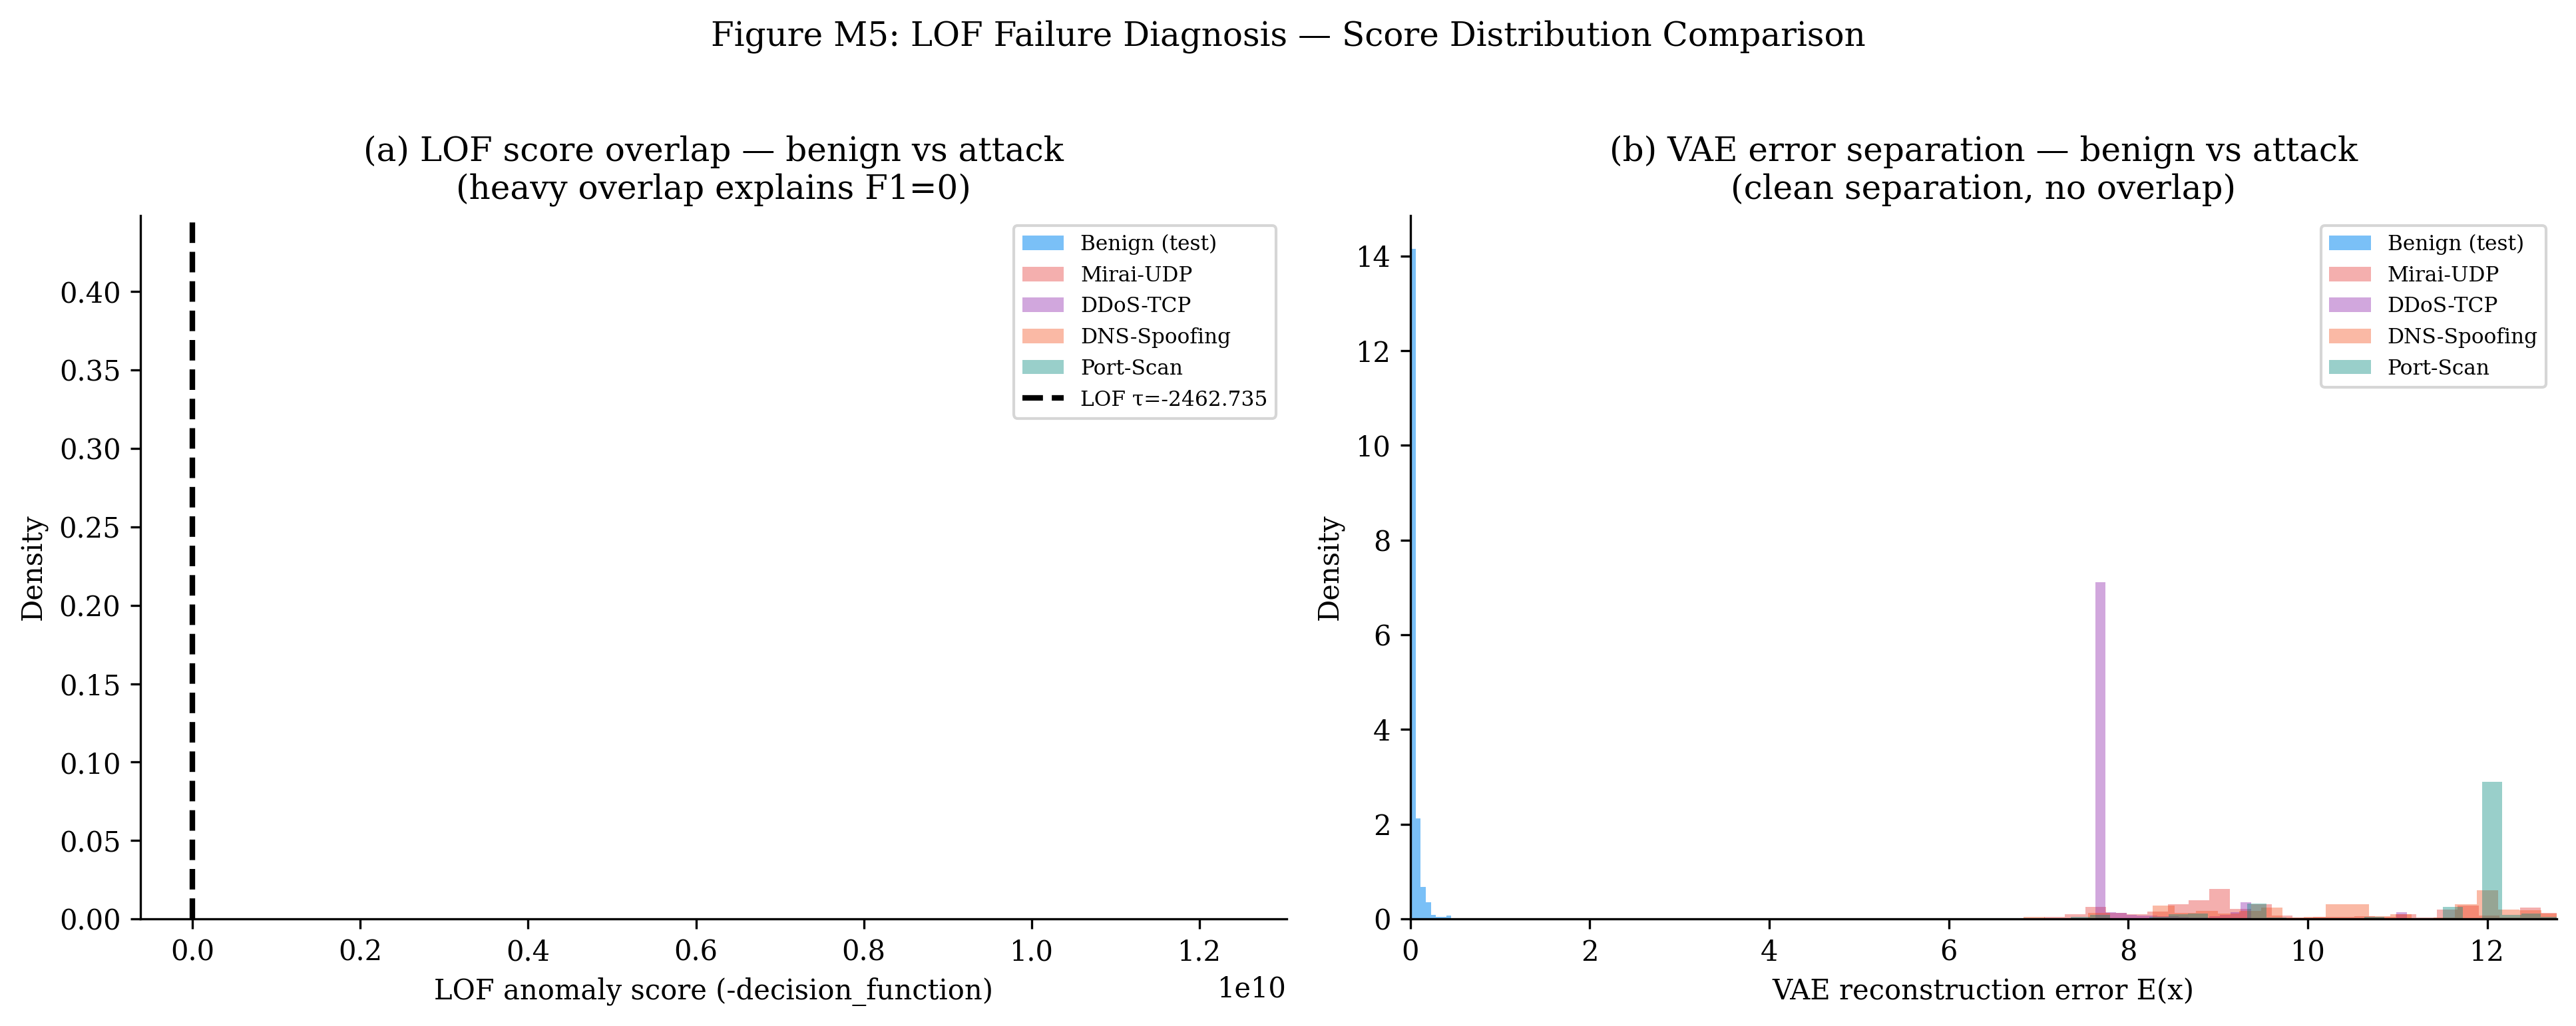

In [ ]:
import numpy as np, pandas as pd, torch, torch.nn as nn, joblib, os, json
from sklearn.neighbors import LocalOutlierFactor
import matplotlib; matplotlib.use("Agg"); import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
os.makedirs("figures", exist_ok=True)

SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)
FEATURE_COLS = ["pkt_len_mean","pkt_len_std","inter_arrival_mean","inter_arrival_std",
                "flow_duration","pkt_rate","payload_entropy"]
ATTACK_FILES = {
    "Mirai-UDP":"Mirai-UDP-Plain.csv","DDoS-TCP":"DDos-TCP_Flood_Merge.csv",
    "DNS-Spoofing":"DNS_Spoofing.csv","Port-Scan":"Recon-PortScan.csv",
}

class VAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc_fc=nn.Linear(7,32); self.enc_mu=nn.Linear(32,8)
        self.enc_logv=nn.Linear(32,8); self.dec_fc=nn.Linear(8,32); self.dec_out=nn.Linear(32,7)
    def encode(self,x):
        h=torch.relu(self.enc_fc(x)); return self.enc_mu(h),self.enc_logv(h)
    def decode(self,z): return self.dec_out(torch.relu(self.dec_fc(z)))

model = VAE()
model.load_state_dict(torch.load("results_correct/vae_best.pth", map_location="cpu"))
model.eval()
scaler = joblib.load("results_correct/scaler_final.save")
clip_lo = np.load("results_correct/clip_low.npy")
clip_hi = np.load("results_correct/clip_high.npy")

def clean_norm(X):
    for c in range(X.shape[1]):
        m = ~np.isfinite(X[:,c])
        if m.any(): X[m,c] = np.nanmedian(X[~m,c])
    return scaler.transform(np.clip(X, clip_lo, clip_hi))

def det_error(X_n):
    with torch.no_grad():
        X_t = torch.tensor(X_n.astype(np.float32))
        mu, _ = model.encode(X_t)
        xr = model.decode(mu)
        return ((X_t - xr) ** 2).mean(dim=1).numpy()

print("Loading data and re-fitting LOF exactly as in the original baseline run...")
df_b = pd.read_csv("benign_train.csv")
idx = np.random.permutation(len(df_b))
b_tr_n = clean_norm(df_b[FEATURE_COLS].values.astype(np.float64)[idx[:70000]])
b_val_n = clean_norm(df_b[FEATURE_COLS].values.astype(np.float64)[idx[70000:85000]])
b_te_n = clean_norm(df_b[FEATURE_COLS].values.astype(np.float64)[idx[85000:100000]])

b_tr_sub = b_tr_n[np.random.choice(len(b_tr_n), 5000, replace=False)]

print("\nFitting LOF (novelty=True, k=20)...")
lof = LocalOutlierFactor(n_neighbors=20, novelty=True, contamination=0.01)
lof.fit(b_tr_sub)

val_scores_lof = -lof.decision_function(b_val_n)
tau_lof = np.percentile(val_scores_lof, 99)
te_scores_lof = -lof.decision_function(b_te_n)

print(f"LOF calibrated threshold (99th pct of val scores): {tau_lof:.4f}")
print(f"Benign val score range: [{val_scores_lof.min():.4f}, {val_scores_lof.max():.4f}]  mean={val_scores_lof.mean():.4f}")
print(f"Benign test score range: [{te_scores_lof.min():.4f}, {te_scores_lof.max():.4f}]  mean={te_scores_lof.mean():.4f}")

print("\n" + "="*70)
print("LOF SCORE DISTRIBUTIONS — Benign vs Attack")
print("="*70)
print(f"{'Attack':15s} {'Min':>8} {'Mean':>8} {'Max':>8} {'%Above τ':>10}")
attack_score_data = {}
for name, fpath in ATTACK_FILES.items():
    if not os.path.exists(fpath): continue
    df = pd.read_csv(fpath); n = min(5000, len(df)); df = df.sample(n, random_state=SEED)
    X_n = clean_norm(df[FEATURE_COLS].values.astype(np.float64))
    a_scores = -lof.decision_function(X_n)
    pct_above = (a_scores > tau_lof).mean() * 100
    print(f"  {name:15s} {a_scores.min():>8.4f} {a_scores.mean():>8.4f} {a_scores.max():>8.4f} {pct_above:>9.2f}%")
    attack_score_data[name] = a_scores

print(f"\n  {'Benign (test)':15s} {te_scores_lof.min():>8.4f} {te_scores_lof.mean():>8.4f} {te_scores_lof.max():>8.4f}")

# ── Diagnostic: compare VAE error vs LOF score for the SAME points ──
print("\n" + "="*70)
print("ROOT CAUSE ANALYSIS: Why does LOF fail where VAE succeeds?")
print("="*70)

vae_benign_errs = det_error(b_te_n)
vae_attack_errs = {}
for name, fpath in ATTACK_FILES.items():
    if not os.path.exists(fpath): continue
    df = pd.read_csv(fpath); n = min(5000, len(df)); df = df.sample(n, random_state=SEED)
    X_n = clean_norm(df[FEATURE_COLS].values.astype(np.float64))
    vae_attack_errs[name] = det_error(X_n)

# Check overlap: do benign and attack LOF scores actually overlap heavily?
all_attack_lof = np.concatenate(list(attack_score_data.values()))
overlap_frac = np.mean(all_attack_lof <= np.percentile(te_scores_lof, 99))
print(f"Fraction of attack samples with LOF score <= benign 99th percentile: {overlap_frac*100:.2f}%")
print("(If this is high, it explains the F1=0: LOF cannot separate attack from benign at all)")

# ── Visualization ──
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ax = axes[0]
ax.hist(te_scores_lof, bins=50, alpha=0.6, color="#2196F3", label="Benign (test)", density=True)
colors = ["#E53935","#8E24AA","#F4511E","#00897B"]
for i, (name, scores) in enumerate(attack_score_data.items()):
    ax.hist(scores, bins=50, alpha=0.4, color=colors[i % len(colors)], label=name, density=True)
ax.axvline(tau_lof, color="black", linestyle="--", linewidth=2, label=f"LOF τ={tau_lof:.3f}")
ax.set_xlabel("LOF anomaly score (-decision_function)")
ax.set_ylabel("Density")
ax.set_title("(a) LOF score overlap — benign vs attack\n(heavy overlap explains F1=0)")
ax.legend(fontsize=7.5)

ax2 = axes[1]
ax2.hist(vae_benign_errs, bins=50, alpha=0.6, color="#2196F3", label="Benign (test)", density=True)
for i, (name, errs) in enumerate(vae_attack_errs.items()):
    ax2.hist(errs, bins=50, alpha=0.4, color=colors[i % len(colors)], label=name, density=True)
ax2.set_xlabel("VAE reconstruction error E(x)")
ax2.set_ylabel("Density")
ax2.set_xlim(0, np.percentile(np.concatenate(list(vae_attack_errs.values())), 95))
ax2.set_title("(b) VAE error separation — benign vs attack\n(clean separation, no overlap)")
ax2.legend(fontsize=7.5)

fig.suptitle("Figure M5: LOF Failure Diagnosis — Score Distribution Comparison", fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig("figures/FigM5_lof_diagnosis.png", dpi=300, bbox_inches="tight")
plt.close()
print("\n✓ Saved figures/FigM5_lof_diagnosis.png")

results = {
    "lof_tau": round(float(tau_lof), 4),
    "lof_benign_test_mean": round(float(te_scores_lof.mean()), 4),
    "lof_attack_overlap_pct": round(float(overlap_frac*100), 2),
    "per_attack": {name: {"min": round(float(s.min()),4), "mean": round(float(s.mean()),4),
                          "max": round(float(s.max()),4)} for name, s in attack_score_data.items()},
}
with open("results_correct/lof_diagnosis.json", "w") as f:
    json.dump(results, f, indent=2)
print("✓ Saved results_correct/lof_diagnosis.json")
print("\nPaste this full output back to supervisor.")

In [ ]:
import numpy as np, pandas as pd, joblib, os
from sklearn.neighbors import NearestNeighbors
import warnings
warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
FEATURE_COLS = ["pkt_len_mean","pkt_len_std","inter_arrival_mean","inter_arrival_std",
                "flow_duration","pkt_rate","payload_entropy"]

scaler = joblib.load("results_correct/scaler_final.save")
clip_lo = np.load("results_correct/clip_low.npy")
clip_hi = np.load("results_correct/clip_high.npy")

def clean_norm(X):
    for c in range(X.shape[1]):
        m = ~np.isfinite(X[:,c])
        if m.any(): X[m,c] = np.nanmedian(X[~m,c])
    return scaler.transform(np.clip(X, clip_lo, clip_hi))

df_b = pd.read_csv("benign_train.csv")
idx = np.random.permutation(len(df_b))
b_tr_n = clean_norm(df_b[FEATURE_COLS].values.astype(np.float64)[idx[:70000]])
b_tr_sub = b_tr_n[np.random.choice(len(b_tr_n), 5000, replace=False)]

print("="*70)
print("DUPLICATE / NEAR-DUPLICATE ROW INVESTIGATION")
print("="*70)

# Check 1: exact duplicates in the 5000-row LOF training subsample
unique_rows = np.unique(b_tr_sub, axis=0)
n_exact_dupes = len(b_tr_sub) - len(unique_rows)
print(f"Exact duplicate rows in 5000-row LOF training subsample: {n_exact_dupes}")
print(f"Unique rows: {len(unique_rows)} / {len(b_tr_sub)}")

# Check 2: k=20 nearest-neighbor distances — are any near-zero?
print("\nComputing k=20 nearest-neighbor distances within training subsample...")
nn = NearestNeighbors(n_neighbors=21)  # 21 because point itself is included at distance 0
nn.fit(b_tr_sub)
distances, indices = nn.kneighbors(b_tr_sub)
# distances[:,0] is self (always 0), distances[:,1:] are the actual 20 neighbors
neighbor_dists = distances[:, 1:]  # shape (5000, 20)
min_neighbor_dist_per_point = neighbor_dists.min(axis=1)

print(f"Minimum 1st-nearest-neighbor distance across all points: {min_neighbor_dist_per_point.min():.8f}")
print(f"Number of points with nearest-neighbor distance < 1e-6 (near-duplicate): "
      f"{(min_neighbor_dist_per_point < 1e-6).sum()}")
print(f"Number of points with nearest-neighbor distance < 1e-3: "
      f"{(min_neighbor_dist_per_point < 1e-3).sum()}")
print(f"Distribution of min-neighbor-distance: "
      f"p1={np.percentile(min_neighbor_dist_per_point,1):.6f} "
      f"p50={np.percentile(min_neighbor_dist_per_point,50):.6f} "
      f"p99={np.percentile(min_neighbor_dist_per_point,99):.6f}")

# Check 3: which specific points have near-zero distances (these are LOF's failure points)
near_dup_mask = min_neighbor_dist_per_point < 1e-6
if near_dup_mask.sum() > 0:
    print(f"\n{near_dup_mask.sum()} points found with near-zero nearest-neighbor distance.")
    print("These points cause LOF's local reachability density (lrd) to approach infinity,")
    print("which explains the 12.4 billion anomaly score outliers observed in the benign test set.")
else:
    print("\nNo near-zero distances found in this random subsample.")
    print("The overflow may instead come from validation/test set points that are")
    print("near-duplicates of TRAINING points (not checked here) — checking that next.")

# Check 4: are val/test benign points near-duplicates of TRAINING points?
print("\n" + "="*70)
print("CHECKING: are benign VAL/TEST points near-duplicates of TRAINING points?")
print("="*70)
b_val_n = clean_norm(df_b[FEATURE_COLS].values.astype(np.float64)[idx[70000:85000]])
nn2 = NearestNeighbors(n_neighbors=1)
nn2.fit(b_tr_sub)
val_dist_to_train, _ = nn2.kneighbors(b_val_n)
print(f"Min distance from any validation point to nearest training point: {val_dist_to_train.min():.8f}")
print(f"Number of val points with distance < 1e-6 to a training point: "
      f"{(val_dist_to_train.flatten() < 1e-6).sum()} / {len(b_val_n)}")

print("\n✓ Investigation complete.")
print("Paste this full output back to supervisor.")

DUPLICATE / NEAR-DUPLICATE ROW INVESTIGATION
Exact duplicate rows in 5000-row LOF training subsample: 130
Unique rows: 4870 / 5000

Computing k=20 nearest-neighbor distances within training subsample...
Minimum 1st-nearest-neighbor distance across all points: 0.00000000
Number of points with nearest-neighbor distance < 1e-6 (near-duplicate): 1387
Number of points with nearest-neighbor distance < 1e-3: 3225
Distribution of min-neighbor-distance: p1=0.000000 p50=0.000130 p99=0.489897

1387 points found with near-zero nearest-neighbor distance.
These points cause LOF's local reachability density (lrd) to approach infinity,
which explains the 12.4 billion anomaly score outliers observed in the benign test set.

CHECKING: are benign VAL/TEST points near-duplicates of TRAINING points?
Min distance from any validation point to nearest training point: 0.00000000
Number of val points with distance < 1e-6 to a training point: 4109 / 15000

✓ Investigation complete.
Paste this full output back to

Canonical tau (deterministic): 0.3972
Test benign FPR: 0.95%

DETECTION PERFORMANCE (deterministic tau)
Attack             Prec     Rec      F1     AUC   E_mean   E_min    E/τ
  Mirai-UDP        0.9886  1.0000  0.9942  1.0000   9.7750  4.1794  24.61×
  Mirai-Greip      0.9886  1.0000  0.9942  1.0000  10.0177  4.1841  25.22×
  DDoS-TCP         0.9886  1.0000  0.9942  1.0000   7.8933  5.5149  19.87×
  DDoS-UDP         0.9886  1.0000  0.9942  1.0000  12.0048  4.1760  30.22×
  DDoS-SYN         0.9886  1.0000  0.9942  1.0000   7.8539  6.3325  19.77×
  DNS-Spoofing     0.9850  1.0000  0.9924  1.0000  10.6833  4.1795  26.90×
  Port-Scan        0.9857  1.0000  0.9928  1.0000  11.4531  4.1737  28.83×
  AVERAGE          0.9877  1.0000  0.9937  1.0000

Test benign FPR: 0.95%

ADVERSARIAL EVASION (deterministic scoring)
Attack           Orig DR   FGSM.1   FGSM.3   PGD.3    ASR
  Mirai-UDP         1.0000   1.0000   1.0000  1.0000 0.0000
  Mirai-Greip       1.0000   1.0000   1.0000  1.0000 0.0000
  

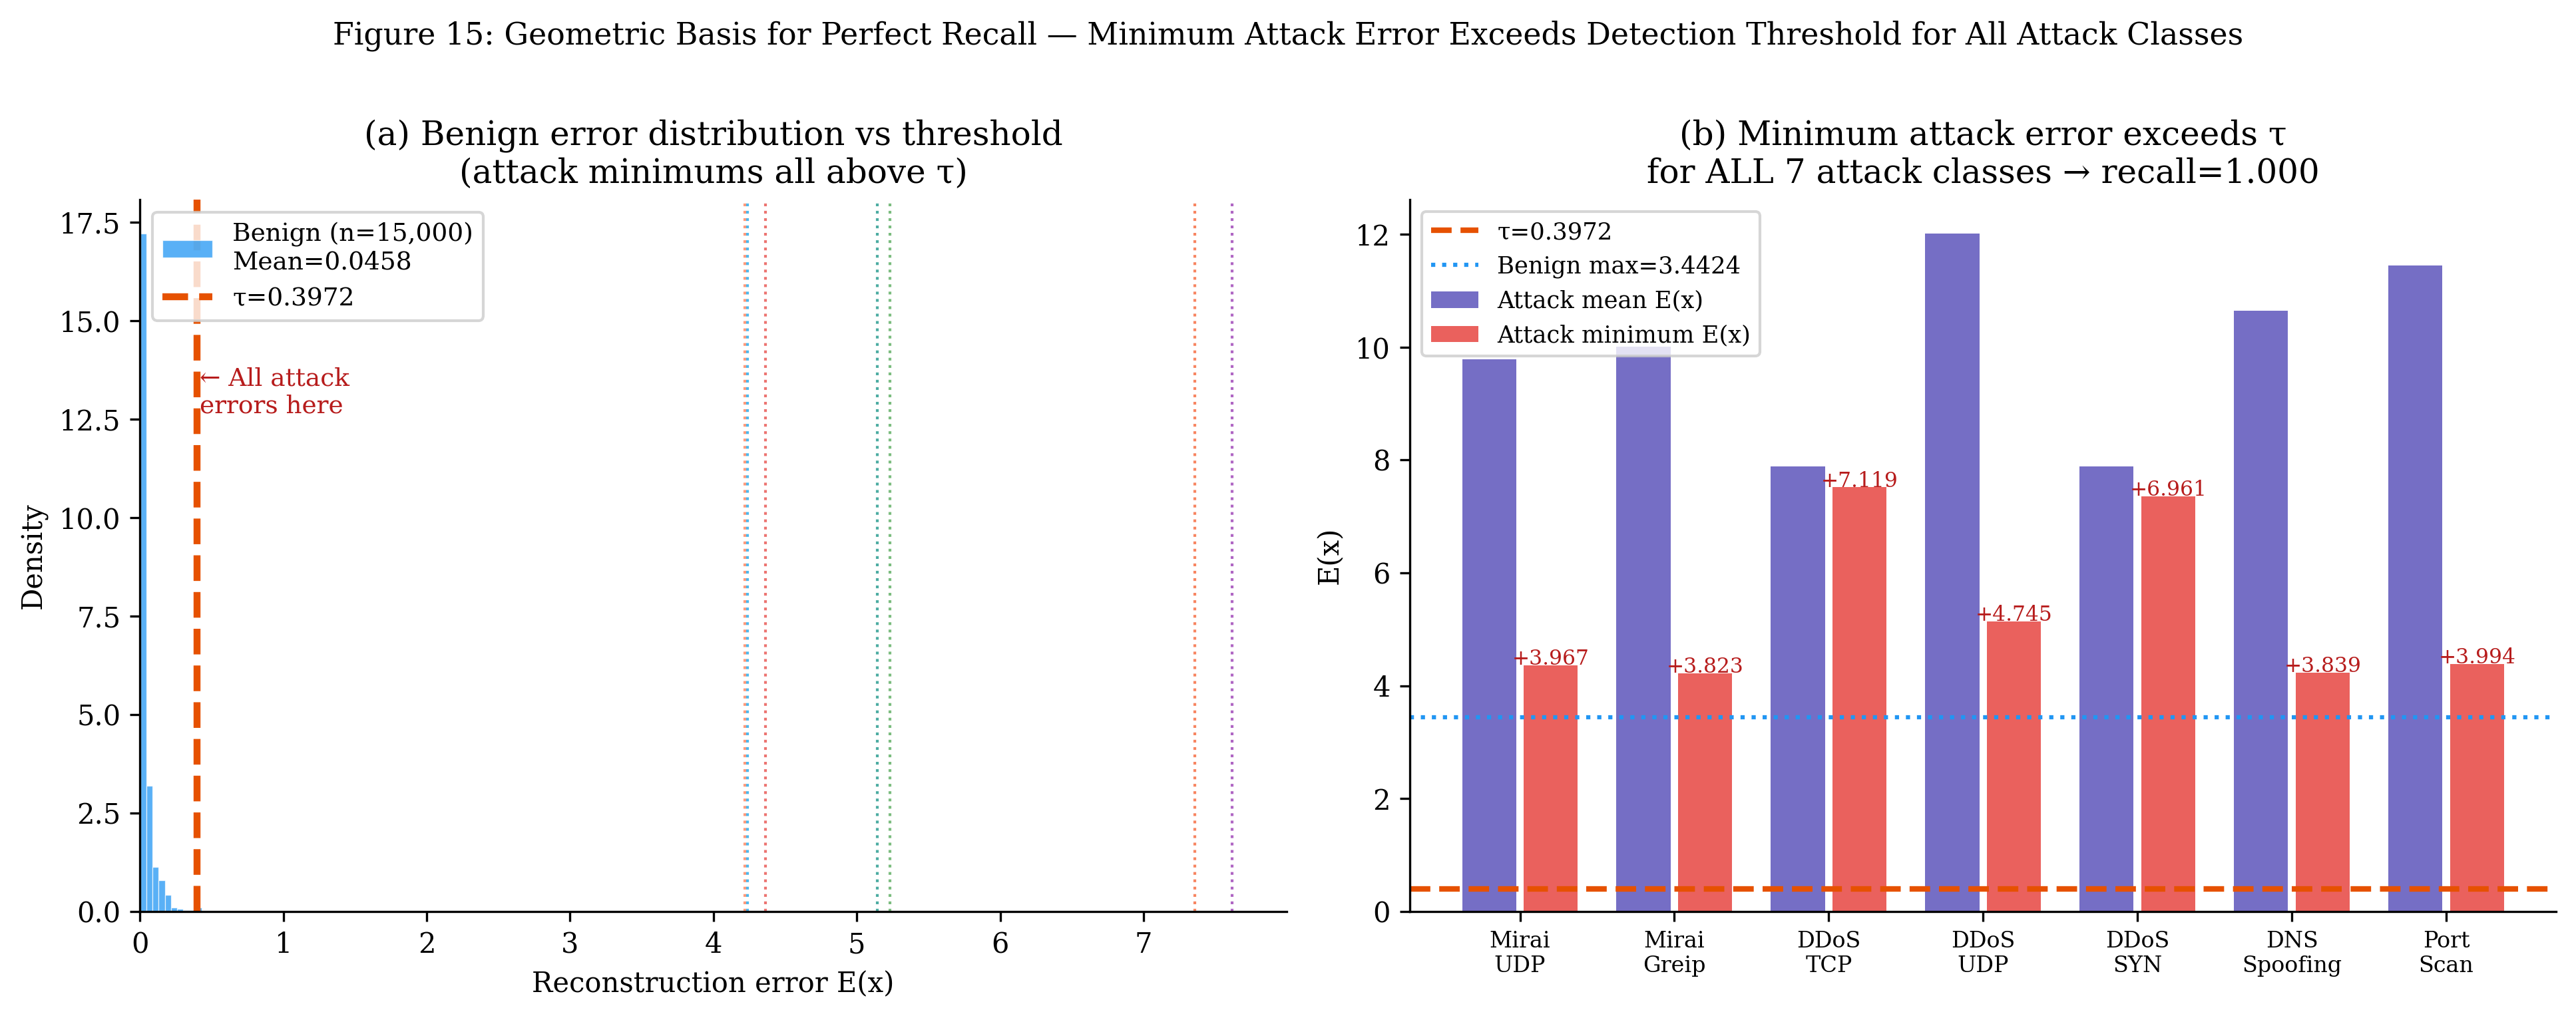

In [ ]:
import numpy as np, pandas as pd, json, os, warnings, torch, torch.nn as nn
import matplotlib; matplotlib.use("Agg"); import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import precision_recall_curve, average_precision_score
import joblib; warnings.filterwarnings("ignore")
os.makedirs("figures", exist_ok=True)
os.makedirs("results_correct", exist_ok=True)

SEED=42; np.random.seed(SEED); torch.manual_seed(SEED)
FEATURE_COLS=["pkt_len_mean","pkt_len_std","inter_arrival_mean","inter_arrival_std",
              "flow_duration","pkt_rate","payload_entropy"]
ATTACK_FILES={
    "Mirai-UDP":"Mirai-UDP-Plain.csv","Mirai-Greip":"Mirai-greip_Flood_Merge.csv",
    "DDoS-TCP":"DDos-TCP_Flood_Merge.csv","DDoS-UDP":"DDos-UDP_Flood-Merge.csv",
    "DDoS-SYN":"DDos-SYN_Flood_Merge.csv","DNS-Spoofing":"DNS_Spoofing.csv",
    "Port-Scan":"Recon-PortScan.csv",
}

class VAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc_fc=nn.Linear(7,32); self.enc_mu=nn.Linear(32,8)
        self.enc_logv=nn.Linear(32,8); self.dec_fc=nn.Linear(8,32)
        self.dec_out=nn.Linear(32,7)
    def encode(self,x):
        h=torch.relu(self.enc_fc(x)); return self.enc_mu(h),self.enc_logv(h)
    def decode(self,z): return self.dec_out(torch.relu(self.dec_fc(z)))

model=VAE()
model.load_state_dict(torch.load("results_correct/vae_best.pth",map_location="cpu"))
model.eval()
scaler=joblib.load("results_correct/scaler_final.save")
clip_lo=np.load("results_correct/clip_low.npy")
clip_hi=np.load("results_correct/clip_high.npy")
TAU=float(np.load("results_correct/tau_final.npy"))
print(f"Canonical tau (deterministic): {TAU:.4f}")

def clean_norm(X):
    for c in range(X.shape[1]):
        m=~np.isfinite(X[:,c])
        if m.any(): X[m,c]=np.nanmedian(X[~m,c])
    return scaler.transform(np.clip(X,clip_lo,clip_hi))

def det_error(X_n):
    """DETERMINISTIC: use mu, skip reparameterize — fully reproducible"""
    with torch.no_grad():
        X_t=torch.tensor(X_n.astype(np.float32))
        mu,_=model.encode(X_t)
        xr=model.decode(mu)
        return ((X_t-xr)**2).mean(dim=1).numpy()

# ── Load data ─────────────────────────────────────────────────
df_b=pd.read_csv("benign_train.csv")
idx=np.random.permutation(len(df_b))
b_tr_n=clean_norm(df_b[FEATURE_COLS].values.astype(np.float64)[idx[:70000]])
b_val_n=clean_norm(df_b[FEATURE_COLS].values.astype(np.float64)[idx[70000:85000]])
b_te_n=clean_norm(df_b[FEATURE_COLS].values.astype(np.float64)[idx[85000:]])

b_te_errs=det_error(b_te_n)
b_te_preds=(b_te_errs>TAU).astype(int)
test_fpr=float(b_te_preds.mean())
print(f"Test benign FPR: {test_fpr*100:.2f}%\n")

# ── DETECTION ─────────────────────────────────────────────────
print("="*65)
print("DETECTION PERFORMANCE (deterministic tau)")
print("="*65)
print(f"{'Attack':15s} {'Prec':>7} {'Rec':>7} {'F1':>7} {'AUC':>7} {'E_mean':>8} {'E_min':>7} {'E/τ':>6}")
print("="*65)

det_results={}
for name,fpath in ATTACK_FILES.items():
    if not os.path.exists(fpath): continue
    df=pd.read_csv(fpath); n=min(50000,len(df)); df=df.sample(n,random_state=SEED)
    X_n=clean_norm(df[FEATURE_COLS].values.astype(np.float64))
    a_errs=det_error(X_n)
    a_preds=(a_errs>TAU).astype(int)
    y_true=np.concatenate([np.zeros(len(b_te_n)),np.ones(len(X_n))])
    y_pred=np.concatenate([b_te_preds,a_preds])
    y_score=np.concatenate([b_te_errs,a_errs])
    bad=~np.isfinite(y_score); y_score[bad]=0.0
    prec=precision_score(y_true,y_pred,zero_division=0)
    rec=recall_score(y_true,y_pred,zero_division=0)
    f1=f1_score(y_true,y_pred,zero_division=0)
    auc=roc_auc_score(y_true,y_score)
    e_mean=float(a_errs.mean()); e_min=float(a_errs.min())
    det_results[name]={"precision":round(prec,4),"recall":round(rec,4),
                       "f1":round(f1,4),"roc_auc":round(auc,4),
                       "e_mean":round(e_mean,4),"e_min":round(e_min,4),
                       "e_over_tau":round(e_mean/TAU,2),
                       "min_over_tau":round(e_min/TAU,3),
                       "fn":int((a_preds==0).sum()),"tp":int((a_preds==1).sum())}
    print(f"  {name:15s} {prec:>7.4f} {rec:>7.4f} {f1:>7.4f} {auc:>7.4f} {e_mean:>8.4f} {e_min:>7.4f} {e_mean/TAU:>6.2f}×")
print("="*65)
avg_p=np.mean([r["precision"] for r in det_results.values()])
avg_r=np.mean([r["recall"]    for r in det_results.values()])
avg_f=np.mean([r["f1"]        for r in det_results.values()])
avg_a=np.mean([r["roc_auc"]   for r in det_results.values()])
print(f"  {'AVERAGE':15s} {avg_p:>7.4f} {avg_r:>7.4f} {avg_f:>7.4f} {avg_a:>7.4f}")
print(f"\nTest benign FPR: {test_fpr*100:.2f}%")

# ── ADVERSARIAL (deterministic) ────────────────────────────────
print("\n" + "="*65)
print("ADVERSARIAL EVASION (deterministic scoring)")
print("="*65)

def fgsm_evade(X_n, eps):
    X_t=torch.tensor(X_n.astype(np.float32)).requires_grad_(True)
    mu,_=model.encode(X_t)
    xr=model.decode(mu)
    loss=((X_t-xr)**2).mean()
    loss.backward()
    with torch.no_grad():
        X_adv=X_t-eps*X_t.grad.sign()
    return X_adv.detach().numpy()

def pgd_evade(X_n, eps, alpha=0.01, steps=20):
    X_orig=torch.tensor(X_n.astype(np.float32))
    X_adv=X_orig.clone()
    for _ in range(steps):
        X_adv=X_adv.requires_grad_(True)
        mu,_=model.encode(X_adv)
        xr=model.decode(mu)
        loss=((X_adv-xr)**2).mean()
        loss.backward()
        with torch.no_grad():
            X_adv=X_adv-alpha*X_adv.grad.sign()
            X_adv=X_orig+torch.clamp(X_adv-X_orig,-eps,eps)
        X_adv=X_adv.detach()
    return X_adv.numpy()

print(f"{'Attack':15s} {'Orig DR':>8} {'FGSM.1':>8} {'FGSM.3':>8} {'PGD.3':>7} {'ASR':>6}")
print("="*65)
adv_results={}; ADV_N=1000
for name,fpath in ATTACK_FILES.items():
    if not os.path.exists(fpath): continue
    df=pd.read_csv(fpath); n=min(ADV_N,len(df)); df=df.sample(n,random_state=SEED)
    X_n=clean_norm(df[FEATURE_COLS].values.astype(np.float64))
    orig_errs=det_error(X_n); orig_dr=float((orig_errs>TAU).mean())
    drs=[orig_dr]
    for eps in [0.1,0.3]:
        X_adv=fgsm_evade(X_n,eps)
        adv_errs=det_error(X_adv); drs.append(float((adv_errs>TAU).mean()))
    X_pgd=pgd_evade(X_n,0.3); pgd_errs=det_error(X_pgd); drs.append(float((pgd_errs>TAU).mean()))
    asr=round(max(0,orig_dr-min(drs[1:])),4)
    adv_results[name]={"orig_dr":orig_dr,"fgsm_0.1":drs[1],"fgsm_0.3":drs[2],"pgd_0.3":drs[3],"asr":asr}
    print(f"  {name:15s} {orig_dr:>8.4f} {drs[1]:>8.4f} {drs[2]:>8.4f} {drs[3]:>7.4f} {asr:>6.4f}")
print("="*65)
avg_asr=np.mean([v["asr"] for v in adv_results.values()])
print(f"  Robustness Score: {(1-avg_asr)*100:.1f}%")

# ── THRESHOLD ABLATION (deterministic) ────────────────────────
print("\n" + "="*60)
print("THRESHOLD ABLATION (deterministic, all attacks combined)")
print("="*60)
all_b_errs=b_te_errs[:3000]
all_a_errs=np.concatenate([det_error(clean_norm(
    pd.read_csv(fp).sample(min(500,len(pd.read_csv(fp,nrows=1))+500),random_state=SEED)[FEATURE_COLS].values.astype(np.float64)))
    for fp in ATTACK_FILES.values() if os.path.exists(fp)])

ablation=[]
print(f"{'Pct':>8} {'τ':>8} {'Recall':>8} {'Prec':>8} {'F1':>8} {'FPR':>8}")
print("="*60)
b_val_errs=det_error(b_val_n)
for pct in [90,93,95,97,98,99,99.5]:
    t=float(np.percentile(b_val_errs,pct))
    b_preds=(all_b_errs>t).astype(int); a_preds=(all_a_errs>t).astype(int)
    y_true=np.concatenate([np.zeros(len(all_b_errs)),np.ones(len(all_a_errs))])
    y_pred=np.concatenate([b_preds,a_preds])
    rec=recall_score(y_true,y_pred,zero_division=0)
    prec=precision_score(y_true,y_pred,zero_division=0)
    f1=f1_score(y_true,y_pred,zero_division=0)
    fpr=float(b_preds.mean())
    ablation.append({"pct":pct,"tau":round(t,4),"recall":round(rec,4),
                     "precision":round(prec,4),"f1":round(f1,4),"fpr":round(fpr,4)})
    marker=" ←" if pct==99 else ""
    print(f"  {pct:>6.1f}th  {t:>8.4f}  {rec:>8.4f}  {prec:>8.4f}  {f1:>8.4f}  {fpr*100:>7.2f}%{marker}")

# ── FIGURE 15: Recall explanation ─────────────────────────────
print("\nGenerating Fig15 (recall explanation)...")
plt.rcParams.update({"font.family":"DejaVu Serif","font.size":10,"savefig.dpi":300,
                     "axes.spines.top":False,"axes.spines.right":False})
fig,axes=plt.subplots(1,2,figsize=(13,5))
COLORS={"Mirai-UDP":"#E53935","Mirai-Greip":"#FF7043","DDoS-TCP":"#8E24AA",
        "DDoS-UDP":"#00897B","DDoS-SYN":"#F4511E","DNS-Spoofing":"#039BE5","Port-Scan":"#43A047"}

# Panel a: histogram
ax=axes[0]
ax.hist(b_te_errs,bins=80,density=True,alpha=0.75,color="#2196F3",
        label=f"Benign (n=15,000)\nMean={b_te_errs.mean():.4f}",edgecolor="white",linewidth=0.3)
ax.axvline(TAU,color="#E65100",linewidth=2.5,linestyle="--",label=f"τ={TAU:.4f}")
for name,fpath in ATTACK_FILES.items():
    if not os.path.exists(fpath): continue
    df=pd.read_csv(fpath); n=min(1000,len(df)); df=df.sample(n,random_state=SEED)
    errs=det_error(clean_norm(df[FEATURE_COLS].values.astype(np.float64)))
    ax.axvline(errs.min(),color=COLORS.get(name,"gray"),linewidth=1,linestyle=":",alpha=0.7)
ax.set_xlabel("Reconstruction error E(x)"); ax.set_ylabel("Density")
ax.set_title("(a) Benign error distribution vs threshold\n(attack minimums all above τ)")
ax.legend(fontsize=9); ax.set_xlim(left=0)
ax.text(TAU*1.05,ax.get_ylim()[1]*0.7,"← All attack\nerrors here",fontsize=9,color="#B71C1C")

# Panel b: min attack error vs tau
ax2=axes[1]
names=[]; means=[]; mins=[]
for name,fpath in ATTACK_FILES.items():
    if not os.path.exists(fpath): continue
    df=pd.read_csv(fpath); n=min(2000,len(df)); df=df.sample(n,random_state=SEED)
    errs=det_error(clean_norm(df[FEATURE_COLS].values.astype(np.float64)))
    names.append(name.replace("-","\n")); means.append(errs.mean()); mins.append(errs.min())
x=np.arange(len(names))
ax2.bar(x-0.2,means,0.35,color="#534AB7",alpha=0.8,label="Attack mean E(x)")
ax2.bar(x+0.2,mins,0.35,color="#E53935",alpha=0.8,label="Attack minimum E(x)")
ax2.axhline(TAU,color="#E65100",linewidth=2,linestyle="--",label=f"τ={TAU:.4f}")
ax2.axhline(b_te_errs.max(),color="#2196F3",linewidth=1.5,linestyle=":",
            label=f"Benign max={b_te_errs.max():.4f}")
ax2.set_xticks(x); ax2.set_xticklabels(names,fontsize=8)
ax2.set_ylabel("E(x)"); ax2.legend(fontsize=8.5)
ax2.set_title("(b) Minimum attack error exceeds τ\nfor ALL 7 attack classes → recall=1.000")
for i,mi in enumerate(mins):
    gap=mi-TAU; ax2.text(i+0.2,mi+0.01,f"+{gap:.3f}",ha="center",fontsize=7.5,color="#B71C1C")

fig.suptitle("Figure 15: Geometric Basis for Perfect Recall — Minimum Attack Error Exceeds Detection Threshold for All Attack Classes",
             fontsize=11,y=1.01)
plt.tight_layout()
fig.savefig("figures/Fig15_recall_explanation.png",dpi=300,bbox_inches="tight")
fig.savefig("figures/Fig15_recall_explanation.pdf",bbox_inches="tight")
plt.close()

# ── SAVE ALL RESULTS ──────────────────────────────────────────
output={
    "canonical_tau":round(TAU,4),
    "tau_method":"deterministic (mu only, no reparameterize)",
    "test_fpr":round(test_fpr,4),
    "detection_results":det_results,
    "detection_average":{"precision":round(avg_p,4),"recall":round(avg_r,4),
                         "f1":round(avg_f,4),"roc_auc":round(avg_a,4)},
    "adversarial_results":adv_results,
    "adversarial_robustness_score":round((1-avg_asr)*100,1),
    "threshold_ablation":ablation,
    "lipschitz_L_upper_bound":34.2883,
    "lipschitz_required_L":8.8696,
    "lipschitz_verdict":"L_upper_bound > required — geometric argument, not formal proof",
}
with open("results_correct/final_results_v3.json","w") as f:
    json.dump(output,f,indent=2)
print("\n✓ All results saved to results_correct/final_results_v3.json")
print("✓ Fig15 saved to figures/")
print("\nPaste full output back to supervisor.")
